# London Rental Map Analysis

Analyse how station positioning affects rental prices nearby.

In [44]:
# import libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from shapely.geometry import Point
import folium
import os
import time
from tqdm.notebook import tqdm
import sys
sys.path.append('..')
from functions.plotting_functions import plot_london, highlight_area, plot_transport, make_interactive_map

In [45]:
plt.rcParams["font.family"] = "Times New Roman"

In [46]:
# directories + load data
base_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
data_dir = os.path.join(base_dir, 'data')

rent_filepath = os.path.join(data_dir,'processed','ons_london_rental_2023_data.csv')
borough_outline_filepath = os.path.join(data_dir,'processed','ldn_borough_outline.geojson')
outcode_outline_filepath = os.path.join(data_dir,'processed','ldn_outcode_outline.geojson')
lsoa_outline_filepath = os.path.join(data_dir,'processed','ldn_LSOA_outline.geojson')
transport_filepath = os.path.join(data_dir,'raw','transport_station_data.csv')

rent = pd.read_csv(rent_filepath)
borough_outline = gpd.read_file(borough_outline_filepath)
outcode_outline = gpd.read_file(outcode_outline_filepath)
lsoa_outline = gpd.read_file(lsoa_outline_filepath)
transport_coords = pd.read_csv(transport_filepath)

## Display processed map data

In [47]:
print('Outcode df')
display(outcode_outline.head())
display(outcode_outline.tail())
display(outcode_outline['JOURNEY_TIME'].describe())
outcode_outline.info()

Outcode df


,OUTCODE,BOROUGH,LON,LAT,JOURNEY_TIME,geometry
0,BR1,Bromley,0.018367,51.412499,70,"MULTIPOLYGON (((0.025 51.396, 0.025 51.395, 0...."
1,BR2,Bromley,0.024608,51.363567,88,"POLYGON ((-0.003 51.346, -0.003 51.346, -0.003..."
2,BR3,Bromley,-0.031427,51.402298,73,"MULTIPOLYGON (((-0.039 51.389, -0.040 51.389, ..."
3,BR4,Bromley,-0.007867,51.374047,82,"POLYGON ((0.016 51.369, 0.015 51.368, 0.015 51..."
4,BR5,Bromley,0.114220,51.379729,96,"POLYGON ((0.101 51.379, 0.101 51.379, 0.101 51..."


,OUTCODE,BOROUGH,LON,LAT,JOURNEY_TIME,geometry
239,W8,Kensington and Chelsea,-0.193552,51.502332,47,"POLYGON ((-0.191 51.498, -0.191 51.498, -0.191..."
240,W9,Westminster,-0.190935,51.526623,48,"POLYGON ((-0.190 51.524, -0.190 51.524, -0.190..."
241,WC1A,Camden,-0.124804,51.515904,29,"POLYGON ((-0.124 51.514, -0.124 51.514, -0.124..."
242,WC1H,Camden,-0.121336,51.525873,37,"POLYGON ((-0.122 51.524, -0.122 51.524, -0.122..."
243,WC1N,Camden,-0.119244,51.521474,36,"POLYGON ((-0.119 51.523, -0.119 51.523, -0.119..."


count    244.000000
mean      57.811475
std       19.696392
min        0.000000
25%       44.000000
50%       56.000000
75%       70.000000
max      158.000000
Name: JOURNEY_TIME, dtype: float64

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   OUTCODE       244 non-null    object  
 1   BOROUGH       244 non-null    object  
 2   LON           244 non-null    float64 
 3   LAT           244 non-null    float64 
 4   JOURNEY_TIME  244 non-null    int64   
 5   geometry      244 non-null    geometry
dtypes: float64(2), geometry(1), int64(1), object(2)
memory usage: 11.6+ KB


In [48]:
print('Borough df')
display(borough_outline.head())
display(borough_outline.tail())
borough_outline.info()

Borough df


,LAT,LON,BOROUGH,geometry
0,51.543951,0.133190,Barking and Dagenham,"POLYGON ((0.098 51.515, 0.097 51.516, 0.097 51..."
1,51.616026,-0.210019,Barnet,"POLYGON ((-0.251 51.573, -0.251 51.573, -0.252..."
2,51.460885,0.142369,Bexley,"POLYGON ((0.108 51.414, 0.108 51.414, 0.108 51..."
3,51.558553,-0.267835,Brent,"POLYGON ((-0.294 51.535, -0.294 51.535, -0.294..."
4,51.638652,0.310753,Brentwood,"POLYGON ((0.261 51.600, 0.260 51.600, 0.260 51..."


,LAT,LON,BOROUGH,geometry
29,51.362077,-0.177587,Sutton,"POLYGON ((-0.207 51.338, -0.207 51.338, -0.208..."
30,51.515732,-0.034655,Tower Hamlets,"POLYGON ((-0.054 51.503, -0.054 51.503, -0.054..."
31,51.594041,-0.012649,Waltham Forest,"POLYGON ((-0.026 51.560, -0.026 51.560, -0.027..."
32,51.451972,-0.186202,Wandsworth,"POLYGON ((-0.213 51.438, -0.214 51.438, -0.214..."
33,51.513440,-0.160454,Westminster,"POLYGON ((-0.188 51.510, -0.188 51.510, -0.188..."


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LAT       34 non-null     float64 
 1   LON       34 non-null     float64 
 2   BOROUGH   34 non-null     object  
 3   geometry  34 non-null     geometry
dtypes: float64(2), geometry(1), object(1)
memory usage: 1.2+ KB


In [49]:
print('Transport df')
display(transport_coords.head())
display(transport_coords.tail())
transport_coords.info()

Transport df


,NAME,TYPE,LAT,LON,ID,PICCADILLY,BAKERLOO,JUBILEE,DISTRICT,NORTHERN,WATERLOO-CITY,VICTORIA,CIRCLE,CENTRAL,METROPOLITAN,HAMMERSMITH-CITY
0,Amersham Underground Station,Tube,51.674206,-0.607362,0400ZZLUAMS0,False,False,False,False,False,False,False,False,False,False,False
1,Chalfont & Latimer Underground Station,Tube,51.667915,-0.560616,0400ZZLUCAL0,False,False,False,False,False,False,False,False,False,False,False
2,Chesham Underground Station,Tube,51.705227,-0.611113,0400ZZLUCSM0,False,False,False,False,False,False,False,False,False,False,False
3,Croxley Underground Station,Tube,51.647069,-0.441746,2100ZZLUCXY0,False,False,False,False,False,False,False,False,False,False,False
4,Chorleywood Underground Station,Tube,51.654292,-0.518319,2100ZZLUCYD0,False,False,False,False,False,False,False,False,False,False,False


,NAME,TYPE,LAT,LON,ID,PICCADILLY,BAKERLOO,JUBILEE,DISTRICT,NORTHERN,WATERLOO-CITY,VICTORIA,CIRCLE,CENTRAL,METROPOLITAN,HAMMERSMITH-CITY
504,Wandle Park Tram Stop,Tram,51.373403,-0.113282,9400ZZCRWAN,False,False,False,False,False,False,False,False,False,False,False
505,West Croydon Tram Stop,Tram,51.378971,-0.101701,9400ZZCRWCR,False,False,False,False,False,False,False,False,False,False,False
506,Wellesley Road Tram Stop,Tram,51.375370,-0.097554,9400ZZCRWEL,False,False,False,False,False,False,False,False,False,False,False
507,Wimbledon Tram Stop,Tram,51.421051,-0.205816,9400ZZCRWMB,False,False,False,False,False,False,False,False,False,False,False
508,Woodside Tram Stop,Tram,51.387100,-0.065361,9400ZZCRWOD,False,False,False,False,False,False,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   NAME              509 non-null    object 
 1   TYPE              509 non-null    object 
 2   LAT               509 non-null    float64
 3   LON               509 non-null    float64
 4   ID                509 non-null    object 
 5   PICCADILLY        509 non-null    bool   
 6   BAKERLOO          509 non-null    bool   
 7   JUBILEE           509 non-null    bool   
 8   DISTRICT          509 non-null    bool   
 9   NORTHERN          509 non-null    bool   
 10  WATERLOO-CITY     509 non-null    bool   
 11  VICTORIA          509 non-null    bool   
 12  CIRCLE            509 non-null    bool   
 13  CENTRAL           509 non-null    bool   
 14  METROPOLITAN      509 non-null    bool   
 15  HAMMERSMITH-CITY  509 non-null    bool   
dtypes: bool(11), float64(2), object(3)
memory us

# Transport

In [50]:
# create dict for colour coding
transport_colours = {'tube':'blue',
                     'elizabeth line':'purple',
                     'dlr':'red',
                     'overground':'orange',
                     'tram':'green',
                     'all':'grey'}

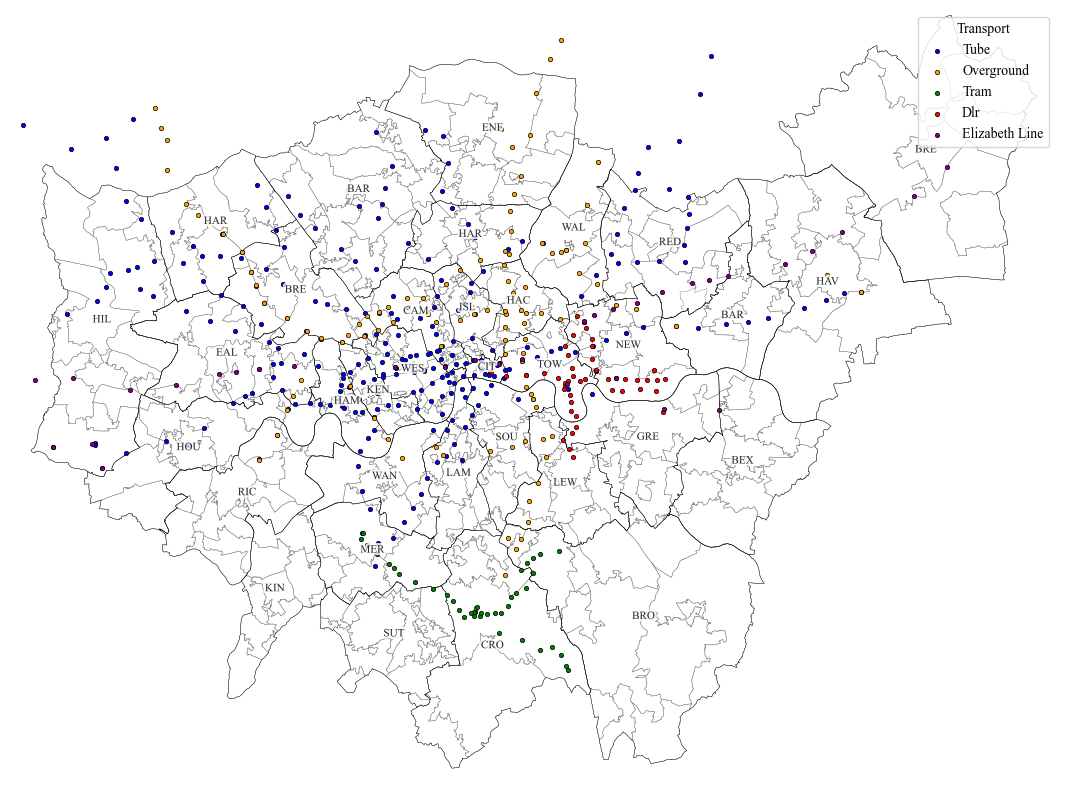

In [51]:
# plot transport stations on map of London
#highlight_areas = ['camden']
#highlighted = outcode_outline[outcode_outline['BOROUGH'].str.contains('|'.join(highlight_areas), case=False)]

plt.figure(figsize=(12,8))
axs=plt.gca()
plot_london(outcode_outline)
plot_london(borough_outline, edgecolour='black', borough=True)
plot_transport(transport_coords, alpha=1)
plt.legend(title='Transport')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'images', 'transport_map_london.png'))
plt.show()

This analysis focuses on the Tube, Overground, DLR, Elizabeth line and Tram services. As shown above, the majority of the selected transport links are concentrated north of the river. Tram services are centred in Croydon while the DLR mainly spans parts of East London.

In [52]:
# find number of stations in each outcode
transport_names = transport_coords.TYPE.unique()
for transport_type in transport_names:
    transport_df = transport_coords.groupby('TYPE').get_group(transport_type)
    for i, outcode in outcode_outline.iterrows():
        outcode_geo = outcode.geometry
        no_stations=0
        for j, station in transport_df.iterrows():
            coord = Point(station.LON, station.LAT)
            if outcode_geo.contains(coord):
                no_stations+=1
        outcode_outline.loc[i, f'NUM_{transport_type.upper()}_STATIONS'] = int(no_stations)

In [53]:
for transport_type in transport_names:
    col = f'NUM_{transport_type.upper()}_STATIONS'
    display(outcode_outline[['OUTCODE', 'BOROUGH']+[col]].nlargest(5, col))

,OUTCODE,BOROUGH,NUM_TUBE_STATIONS
28,E1,City of London,14.0
112,NW1,Camden,13.0
113,NW10,Brent,9.0
60,HA1,Brent,8.0
136,SE1,Lambeth,8.0


,OUTCODE,BOROUGH,NUM_ELIZABETH LINE_STATIONS
28,E1,City of London,3.0
34,E15,Hackney,3.0
203,TW14,Hillingdon,3.0
72,IG3,Redbridge,2.0
8,CM13,Havering,1.0


,OUTCODE,BOROUGH,NUM_DLR_STATIONS
33,E14,Tower Hamlets,14.0
35,E16,Newham,12.0
34,E15,Hackney,6.0
28,E1,City of London,4.0
137,SE10,Greenwich,3.0


,OUTCODE,BOROUGH,NUM_OVERGROUND_STATIONS
28,E1,City of London,5.0
36,E17,Waltham Forest,5.0
45,E8,Hackney,5.0
95,N15,Hackney,5.0
119,NW6,Brent,5.0


,OUTCODE,BOROUGH,NUM_TRAM_STATIONS
13,CR0,Croydon,24.0
2,BR3,Bromley,5.0
16,CR4,Croydon,4.0
179,SW19,Merton,4.0
153,SE25,Croydon,3.0


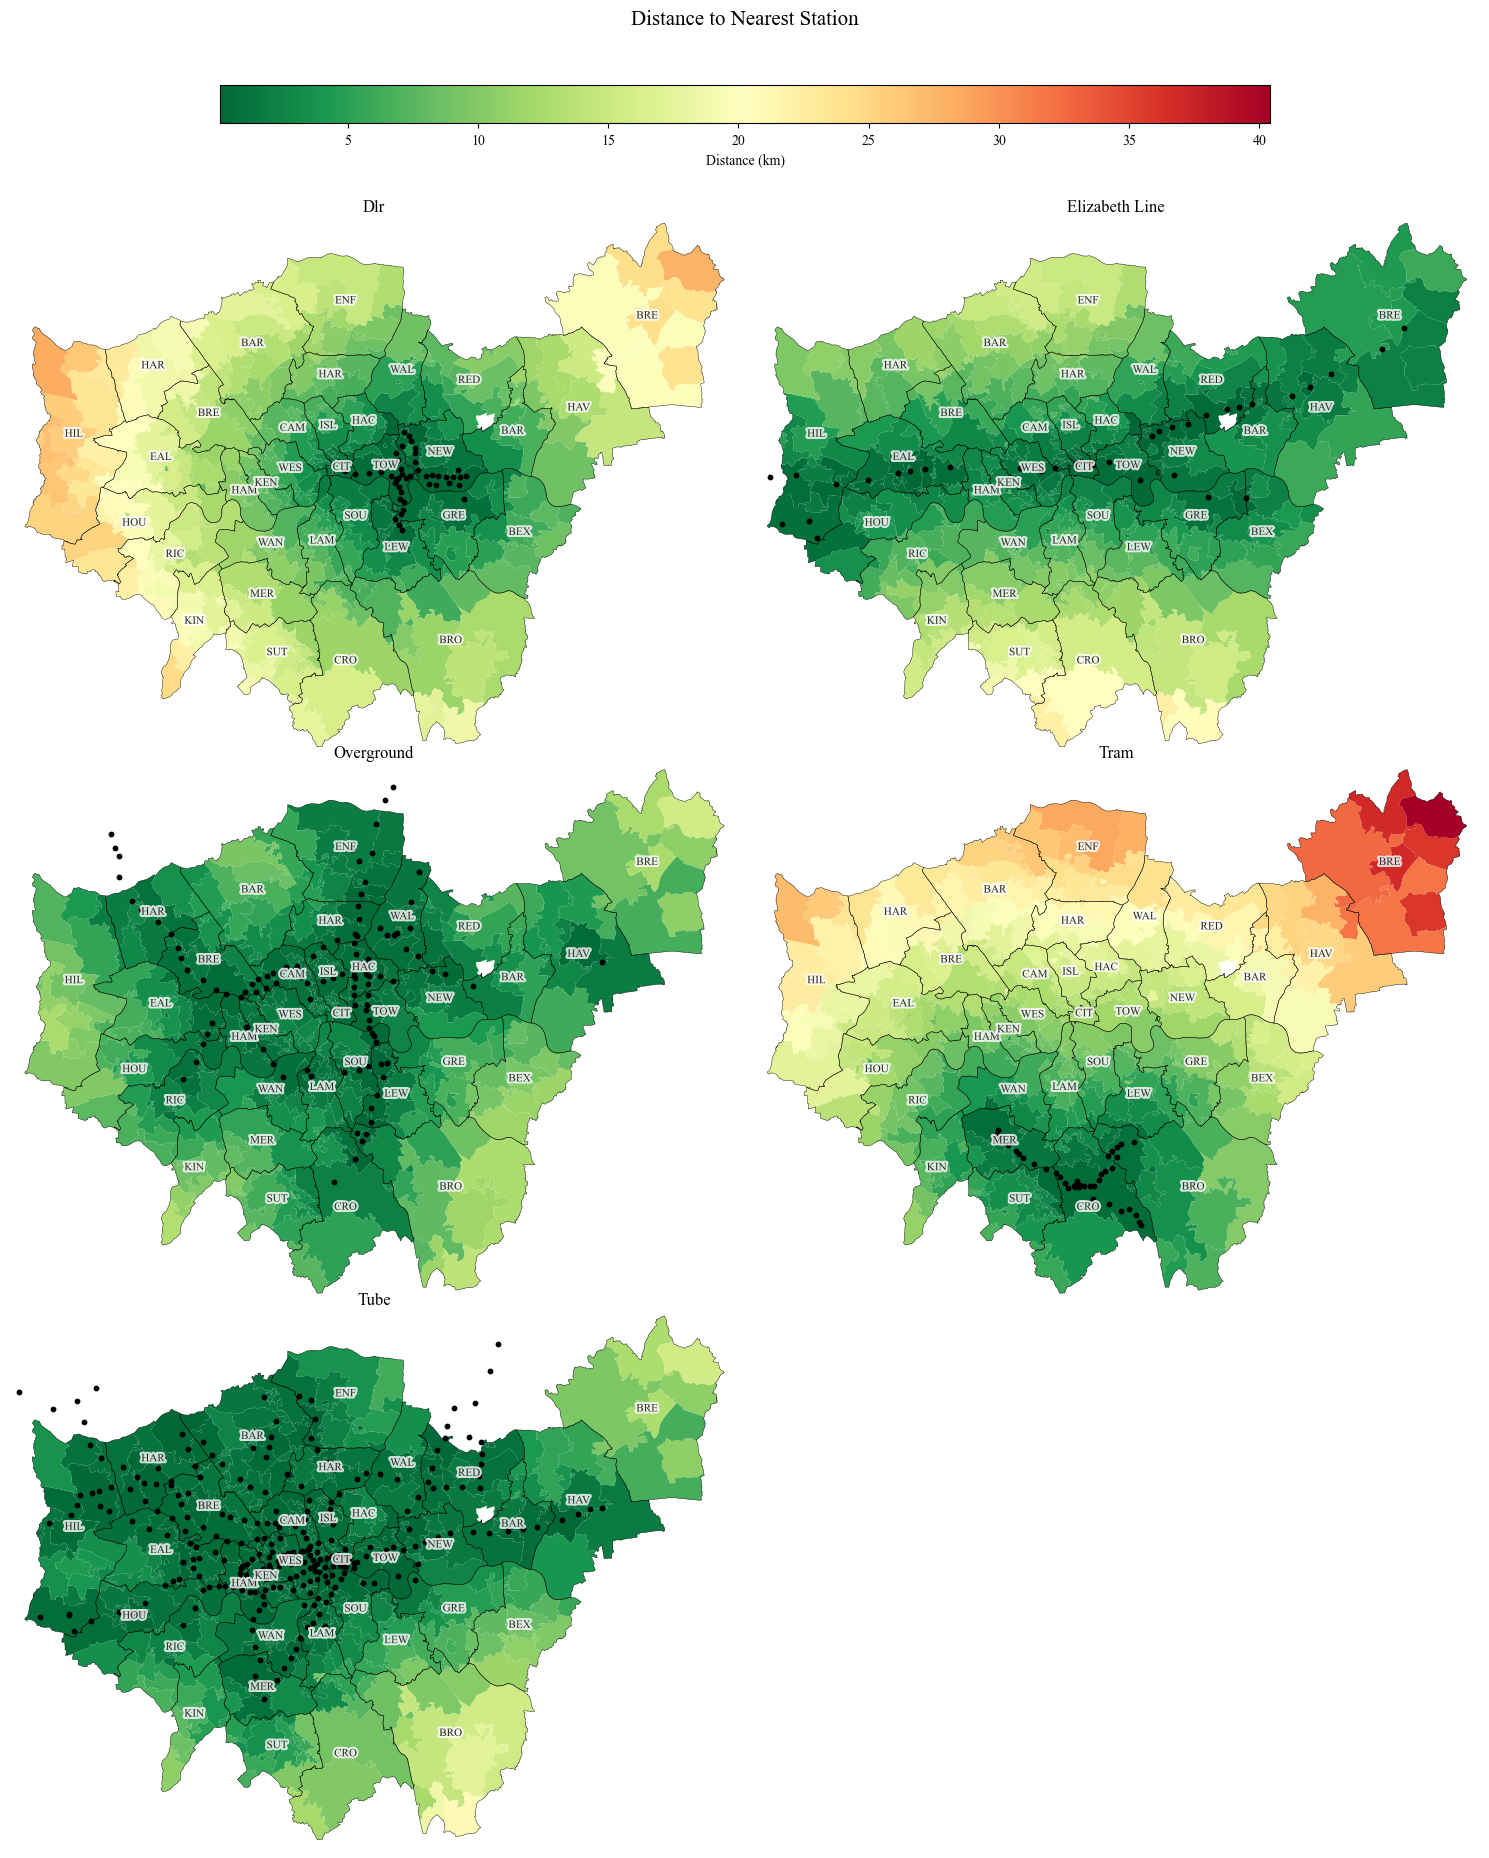

In [54]:
# heatmap of distance to nearest station
from sklearn.neighbors import BallTree

grouped_transport_coords = transport_coords.groupby('TYPE')

earth_radius = 6371
all_dists=[]
for transport in transport_names:
    df = grouped_transport_coords.get_group(transport)
    tree = BallTree(np.deg2rad(df[['LAT', 'LON']]), metric='haversine')
    dist_radians, ind = tree.query(np.deg2rad(outcode_outline[['LAT','LON']]), k=1)
    outcode_outline[f'NEAREST_{transport.upper()}_STATION'] = df.iloc[ind.flatten()]['NAME'].to_list()
    outcode_outline[f'DIST_TO_{transport.upper()}_STATION'] = dist_radians.flatten()*earth_radius # dist in km
    all_dists.extend(dist_radians.flatten()*earth_radius)

dist_min = min(all_dists)
dist_max = max(all_dists)
norm = plt.Normalize(dist_min, dist_max) #None

fig, axs = plt.subplots(3,2, figsize=(15, 19))
axs=axs.flatten()
for i, (transport, df) in enumerate(transport_coords.groupby('TYPE')):
    ax = axs[i]
    mappable = plot_london(outcode_outline, col=f'DIST_TO_{transport.upper()}_STATION', norm=norm, cmap='RdYlGn_r', legend=False, ax=ax, return_mappable=True)
    plot_london(borough_outline, edgecolour='black', borough=True, ax=ax)
    ax.scatter(df['LON'], df['LAT'], s=10, color='black')
    ax.set_title(transport)
axs[5].remove()
plt.suptitle('Distance to Nearest Station', fontsize=15)
plt.tight_layout(rect=[0,0,1,0.9])

cbar_ax = fig.add_axes([0.15, 0.92, 0.7, 0.02])
plt.colorbar(mappable, label='Distance (km)', orientation='horizontal', cax=cbar_ax)
plt.savefig(os.path.join(base_dir, 'images', 'distance_to_station_map.png'))
plt.show()

# Rent

In [55]:
print('Rent df')
display(rent.head())
display(rent.tail())
rent.info()

Rent df


,OUTCODE,ROOM_TYPE,NO_ROOMS,RENT_COUNT,MEAN_RENT,LQ_RENT,MEDIAN_RENT,UQ_RENT
0,BR1,Room,1,10,703,0,688,0
1,BR1,Studio,1,10,954,900,972,1000
2,BR1,One Bedroom,1,180,1230,1100,1250,1350
3,BR1,Two Bedrooms,2,250,1513,1350,1500,1650
4,BR1,Three Bedrooms,3,90,1859,1600,1800,2000


,OUTCODE,ROOM_TYPE,NO_ROOMS,RENT_COUNT,MEAN_RENT,LQ_RENT,MEDIAN_RENT,UQ_RENT
1969,WD6,Studio,1,0,0,0,0,0
1970,WD6,One Bedroom,1,0,0,0,0,0
1971,WD6,Two Bedrooms,2,0,0,0,0,0
1972,WD6,Three Bedrooms,3,0,0,0,0,0
1973,WD6,Four or More Bedrooms,4,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   OUTCODE      1974 non-null   object
 1   ROOM_TYPE    1974 non-null   object
 2   NO_ROOMS     1974 non-null   int64 
 3   RENT_COUNT   1974 non-null   int64 
 4   MEAN_RENT    1974 non-null   int64 
 5   LQ_RENT      1974 non-null   int64 
 6   MEDIAN_RENT  1974 non-null   int64 
 7   UQ_RENT      1974 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 123.5+ KB


In [56]:
# merge outcode polygons with the rent data
dist_cols = outcode_outline.columns[outcode_outline.columns.str.contains('DIST')].tolist()
rent_dist_geometry = pd.merge(rent[['OUTCODE', 'ROOM_TYPE', 'NO_ROOMS', 'RENT_COUNT', 'MEDIAN_RENT']], outcode_outline[['BOROUGH', 'OUTCODE', 'JOURNEY_TIME', 'geometry'] + dist_cols], on='OUTCODE', how='inner')
rent_dist_geometry.insert(3, 'MEDIAN_RENT_PR', rent_dist_geometry['MEDIAN_RENT']//rent_dist_geometry['NO_ROOMS']) # add rent per room col
rent_dist_geometry = gpd.GeoDataFrame(rent_dist_geometry, geometry=rent_dist_geometry['geometry'], crs="EPSG:4326")
rent_dist_geometry[['MEDIAN_RENT_PR','MEDIAN_RENT']] = rent_dist_geometry[['MEDIAN_RENT_PR','MEDIAN_RENT']].replace(0, np.nan)

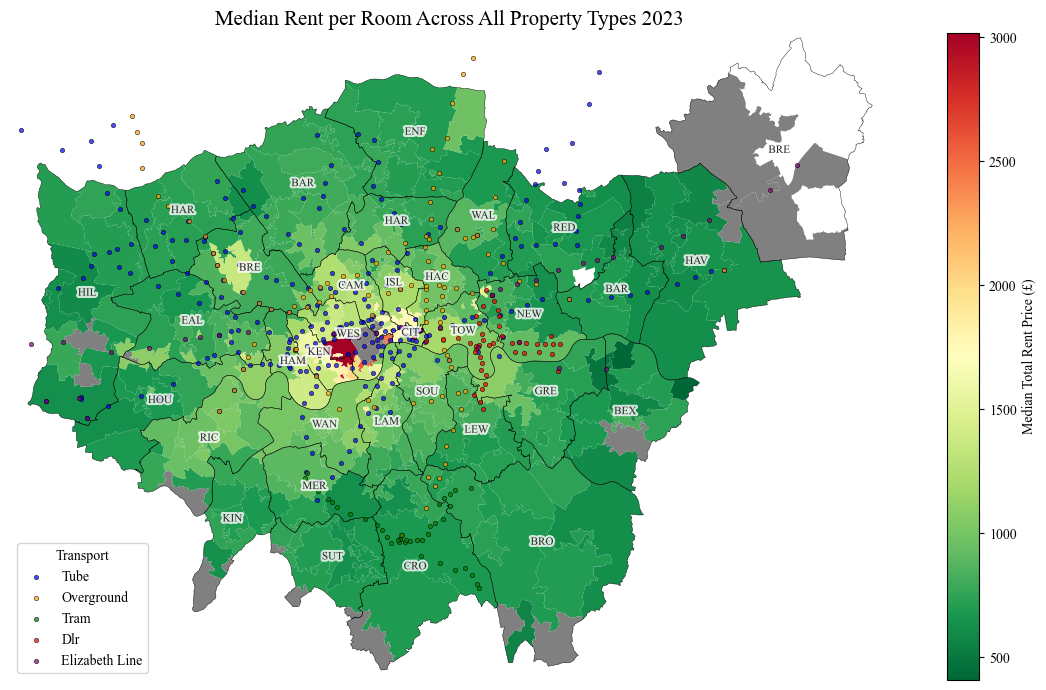

In [57]:
# combine median rent of all rooms for each outcode
combined_room_rent_geometry = rent_dist_geometry[['OUTCODE', 'MEDIAN_RENT_PR']].groupby('OUTCODE').median().reset_index().merge(rent_dist_geometry[['OUTCODE', 'geometry']], how='inner', on='OUTCODE')
combined_room_rent_geometry = gpd.GeoDataFrame(combined_room_rent_geometry, geometry=combined_room_rent_geometry['geometry'], crs="EPSG:4326")
combined_room_rent_geometry['MEDIAN_RENT_PR'] = combined_room_rent_geometry['MEDIAN_RENT_PR'].replace(0, np.nan)
combined_room_rent_geometry = combined_room_rent_geometry.drop_duplicates().reset_index(drop=True)

# plot the rent price per outcode on map
plt.figure(figsize=(12,7))
plot_london(combined_room_rent_geometry, col='MEDIAN_RENT_PR', cmap='RdYlGn_r', legend=True, leg_label='Median Total Rent Price (£)')
plot_london(borough_outline, borough=True, edgecolour='black')
plot_transport(transport_coords)
plt.title('Median Rent per Room Across All Property Types 2023', fontsize=15)
plt.legend(title='Transport')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'images', 'median_combined_rental_prices_map.png'))
plt.show()

# make and save an interactive map
make_interactive_map(combined_room_rent_geometry, 'MEDIAN_RENT_PR', borough_gdf=borough_outline, key='OUTCODE', cmap='RdYlGn_r',
                     title='Median Rent per Room by By Outcode (£)', leg_label='Rent (£)', transport_coords=transport_coords,
                     highlight_cols=['OUTCODE', 'MEDIAN_RENT_PR'], highlight_aliases=['Outcode: ','Rent: '],
                     filepath=os.path.join(base_dir, 'interactive_maps', 'median_rent_per_room_map.html'))

In [58]:
print('Top 5 lowest rents per room: ')
display(rent_dist_geometry.nsmallest(5, 'MEDIAN_RENT_PR')[['OUTCODE','ROOM_TYPE','BOROUGH','MEDIAN_RENT_PR','MEDIAN_RENT']])
print('Top 5 highest rents per room: ')
display(rent_dist_geometry.nlargest(5, 'MEDIAN_RENT_PR')[['OUTCODE','ROOM_TYPE','BOROUGH','MEDIAN_RENT_PR','MEDIAN_RENT']])

Top 5 lowest rents per room: 


,OUTCODE,ROOM_TYPE,BOROUGH,MEDIAN_RENT_PR,MEDIAN_RENT
125,DA18,Four or More Bedrooms,Bexley,350.0,1400.0
869,SE2,Four or More Bedrooms,Bexley,375.0,1500.0
124,DA18,Three Bedrooms,Bexley,408.0,1225.0
761,RM2,Four or More Bedrooms,Havering,425.0,1700.0
868,SE2,Three Bedrooms,Bexley,428.0,1285.0


Top 5 highest rents per room: 


,OUTCODE,ROOM_TYPE,BOROUGH,MEDIAN_RENT_PR,MEDIAN_RENT
1100,SW1X,One Bedroom,Kensington and Chelsea,4010.0,4010.0
1070,SW1E,One Bedroom,Westminster,3792.0,3792.0
584,N1C,One Bedroom,Camden,3738.0,3738.0
1077,SW1H,Two Bedrooms,Kensington and Chelsea,3510.0,7020.0
1101,SW1X,Two Bedrooms,Kensington and Chelsea,3016.0,6033.0


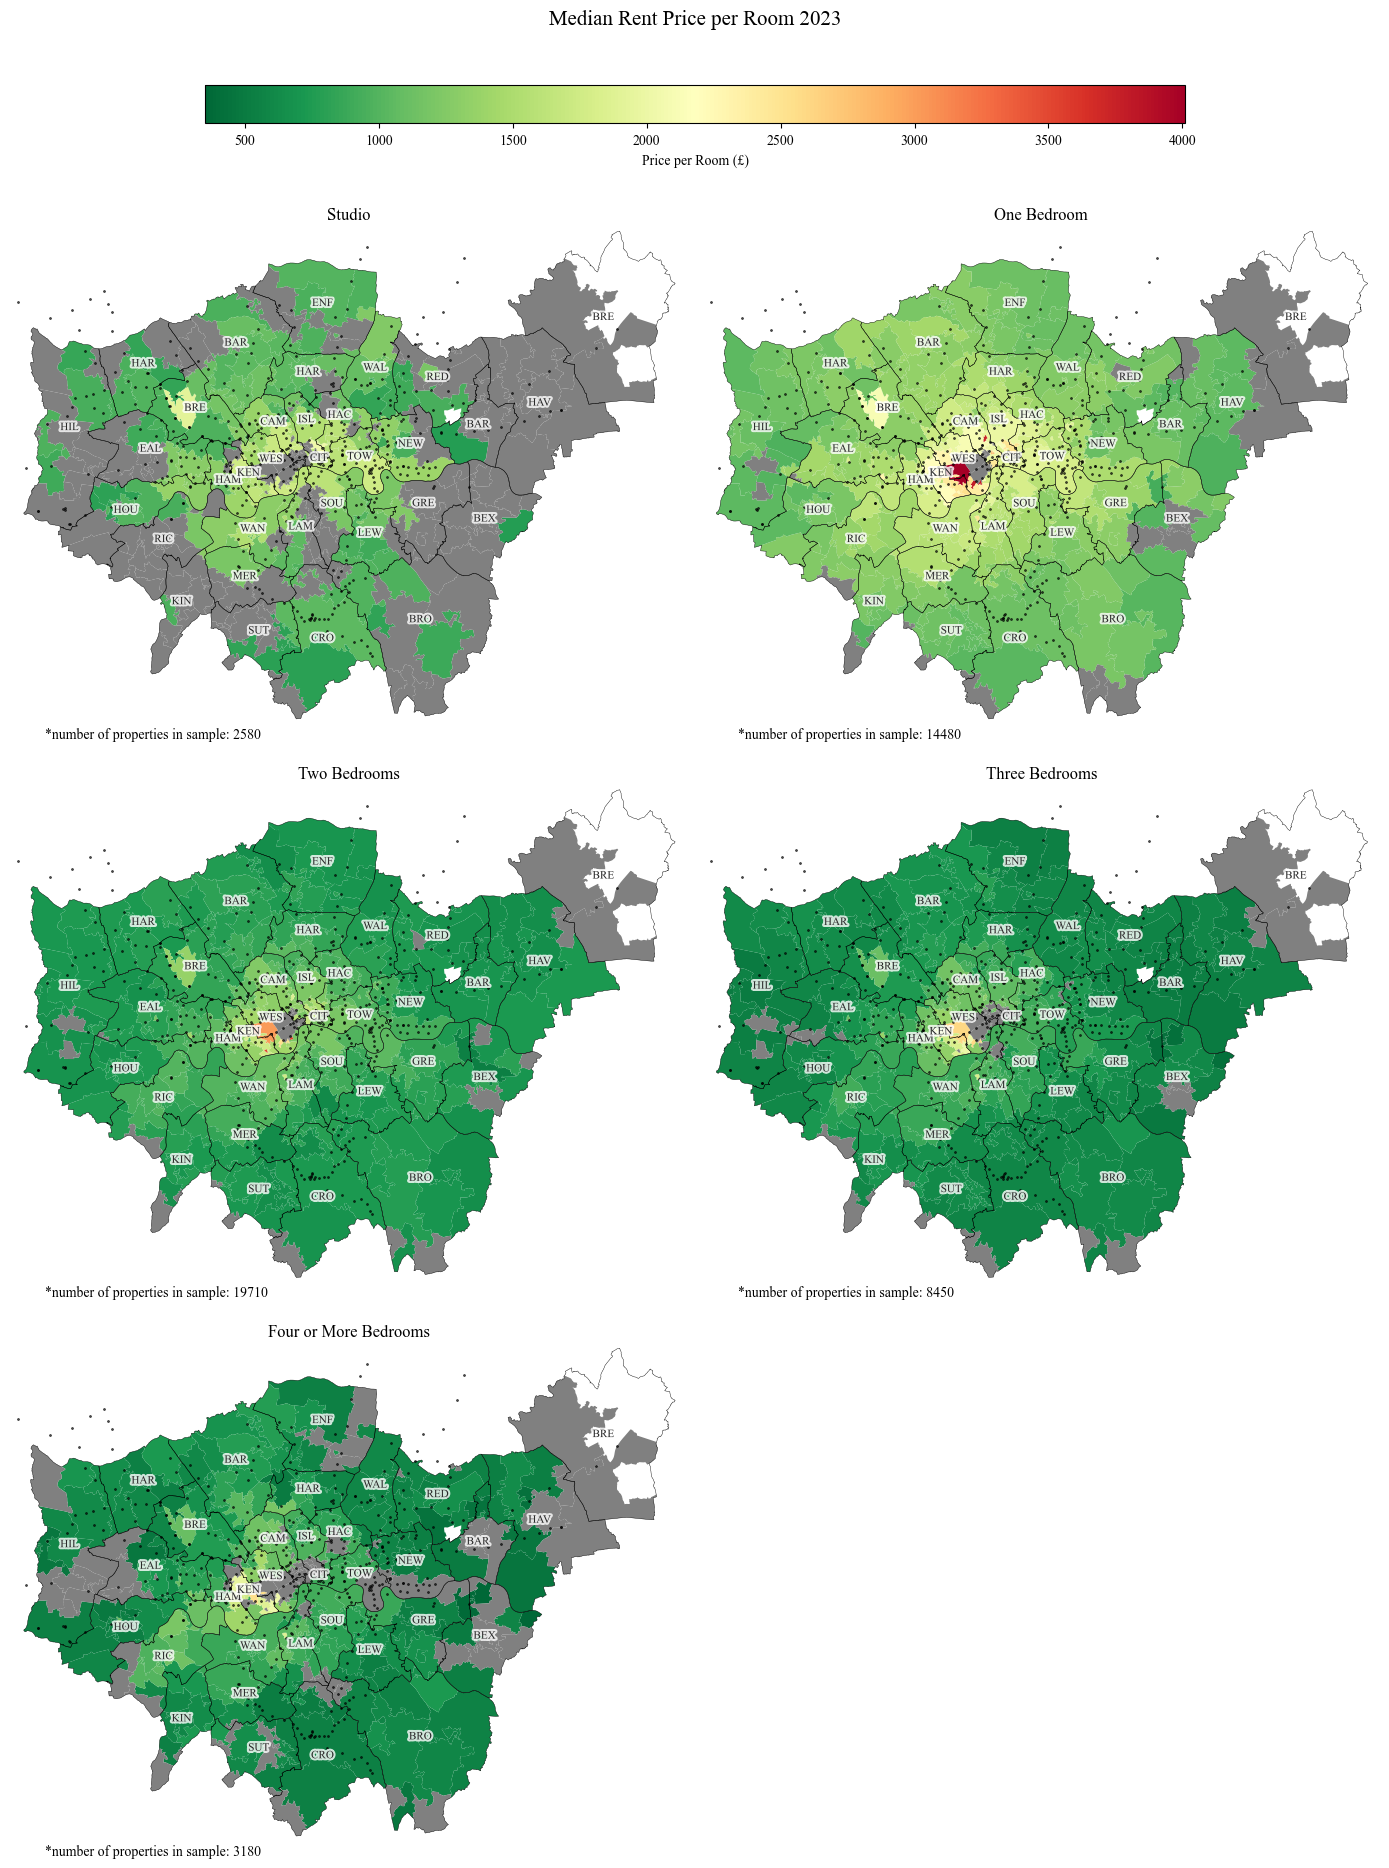

Lowest median rent: £350.0
Highest median rent: £4010.0


In [59]:
# median rent per room across London grouped by number of rooms per property
grouped_rent = rent_dist_geometry.groupby(['ROOM_TYPE'])
rooms = ['Studio', 'One Bedroom', 'Two Bedrooms', 'Three Bedrooms', 'Four or More Bedrooms']

# normalise rent data across every all room types
rent_min = rent_dist_geometry['MEDIAN_RENT_PR'][rent_dist_geometry['MEDIAN_RENT_PR']!=0].min()
rent_max = rent_dist_geometry['MEDIAN_RENT_PR'].max()
norm = plt.Normalize(rent_min, rent_max)

fig, axs = plt.subplots(3,2, figsize=(14,19))
plt.suptitle('Median Rent Price per Room 2023', fontsize=15)
axs = axs.flatten()

for i, room in enumerate(rooms):
    ax=axs[i]
    df = grouped_rent.get_group((room,))
    mappable = plot_london(df, col='MEDIAN_RENT_PR', norm=norm, cmap='RdYlGn_r', legend=False, ax=ax, return_mappable=True)
    plot_london(borough_outline, borough=True, edgecolour='black', ax=ax)
    plot_transport(transport_coords, s=2, colour='black', ax=ax)
    ax.set_title(f'\n\n\n{room}', fontsize=12)
    ax.text(ax.get_xlim()[0]+0.05,ax.get_ylim()[0]-0.01,f'*number of properties in sample: {df.RENT_COUNT.sum()}')

# remove empty axes
[fig.delaxes(ax) for ax in axs if not ax.has_data()]
plt.tight_layout(rect=[0, 0, 1, 0.92])

# add colourbar
cbar_ax = fig.add_axes([0.15, 0.92, 0.7, 0.02])
plt.colorbar(mappable, label='Price per Room (£)', orientation='horizontal', cax=cbar_ax)

plt.savefig(os.path.join(base_dir, 'images', 'median_rental_price_by_room_map.png'))
plt.show()
print(f"Lowest median rent: £{rent_min}\nHighest median rent: £{rent_max}")

The median rent per room across London outcodes in 2023 ranged from £350 to £4010. As expected, rents increase closer to the city centre, with West London also showing slighter higher rent. The most expensive rents were for one-bedroom proprties in Westminster and Kensington & Chelsea, which aligns with the heavy concentration of tube stations in the area.

An outcode (HA9) in Wembley, Brent, consistently has higher rental prices than the surrounding areas. This is likely due to a shortage of rental properties in the area, allowing landlords to charge a premium. [https://www.brent.gov.uk/housing/renting-in-the-private-sector/find-a-place-you-can-afford]

In [60]:
# find highest rent percentage drop when no. of bedrooms increase
rent_pct_change = rent_dist_geometry[rent_dist_geometry['ROOM_TYPE']!='Room'][['BOROUGH', 'OUTCODE', 'RENT_COUNT', 'ROOM_TYPE', 'NO_ROOMS', 'MEDIAN_RENT_PR', 'geometry']].copy()
grouped_df = rent_pct_change.groupby(by=['OUTCODE'])
for i, group in grouped_df:
    group = group.sort_values('NO_ROOMS')
    inds = group.index
    rent_pct_change.loc[inds, 'RENT_PCT_CHANGE'] = group['MEDIAN_RENT_PR'].pct_change(fill_method=None)*100
rent_pct_change['ABS_RENT_PCT_CHANGE'] = abs(rent_pct_change['RENT_PCT_CHANGE'])

print('Areas with largest INCREASE in rent as number of rooms increase' )
display(rent_pct_change.nlargest(10, 'RENT_PCT_CHANGE').drop(columns=['geometry','ABS_RENT_PCT_CHANGE']))
print('Areas with largest DECREASE in rent as number of rooms increase' )
display(rent_pct_change.nsmallest(10, 'RENT_PCT_CHANGE').drop(columns=['geometry','ABS_RENT_PCT_CHANGE']))
print('Areas with smallest change in rent as number of rooms increase' )
display(rent_pct_change.nsmallest(10, 'ABS_RENT_PCT_CHANGE').drop(columns=['geometry','ABS_RENT_PCT_CHANGE']))

Areas with largest INCREASE in rent as number of rooms increase


,BOROUGH,OUTCODE,RENT_COUNT,ROOM_TYPE,NO_ROOMS,MEDIAN_RENT_PR,RENT_PCT_CHANGE
1250,Richmond upon Thames,TW9,20,One Bedroom,1,1630.0,71.940928
620,Hackney,N4,90,One Bedroom,1,1600.0,68.421053
632,Camden,N6,40,One Bedroom,1,1665.0,67.336683
1337,Hammersmith and Fulham,W11,10,Four or More Bedrooms,4,1952.0,66.837607
1118,Kensington and Chelsea,SW3,130,One Bedroom,1,2475.0,59.677419
1382,Ealing,W2,130,One Bedroom,1,2300.0,58.839779
1418,Kensington and Chelsea,W8,80,One Bedroom,1,2318.0,57.365920
206,Redbridge,E18,70,One Bedroom,1,1339.0,56.975381
1077,Kensington and Chelsea,SW1H,10,Two Bedrooms,2,3510.0,56.000000
404,Barking and Dagenham,IG11,130,One Bedroom,1,1200.0,54.838710


Areas with largest DECREASE in rent as number of rooms increase


,BOROUGH,OUTCODE,RENT_COUNT,ROOM_TYPE,NO_ROOMS,MEDIAN_RENT_PR,RENT_PCT_CHANGE
879,Lambeth,SE21,70,Two Bedrooms,2,620.0,-56.794425
1443,Camden,WC1N,20,Two Bedrooms,2,1300.0,-53.851615
585,Camden,N1C,10,Two Bedrooms,2,1841.0,-50.749064
1257,Ealing,UB1,10,Two Bedrooms,2,725.0,-50.000000
327,Barnet,EN4,50,Two Bedrooms,2,650.0,-49.534161
915,Lambeth,SE27,20,Two Bedrooms,2,750.0,-48.275862
255,Hackney,E8,130,Two Bedrooms,2,975.0,-48.138298
81,Croydon,CR4,100,Two Bedrooms,2,625.0,-46.808511
921,Bexley,SE28,30,Two Bedrooms,2,745.0,-46.785714
117,Bexley,DA17,20,Two Bedrooms,2,700.0,-46.153846


Areas with smallest change in rent as number of rooms increase


,BOROUGH,OUTCODE,RENT_COUNT,ROOM_TYPE,NO_ROOMS,MEDIAN_RENT_PR,RENT_PCT_CHANGE
248,Newham,E7,30,One Bedroom,1,1150.0,0.000000
311,Enfield,EN1,20,Four or More Bedrooms,4,550.0,0.000000
496,Kingston upon Thames,KT5,50,Three Bedrooms,3,700.0,0.000000
809,Greenwich,SE10,10,Four or More Bedrooms,4,875.0,0.000000
1409,Hammersmith and Fulham,W6,20,Four or More Bedrooms,4,1000.0,0.000000
449,Redbridge,IG8,20,Four or More Bedrooms,4,581.0,-0.343053
1343,Ealing,W12,20,Four or More Bedrooms,4,887.0,-0.448934
665,Brent,NW10,10,Four or More Bedrooms,4,754.0,0.533333
335,Barnet,EN5,10,Four or More Bedrooms,4,687.0,0.585652
677,Barnet,NW2,20,Four or More Bedrooms,4,728.0,-0.682128


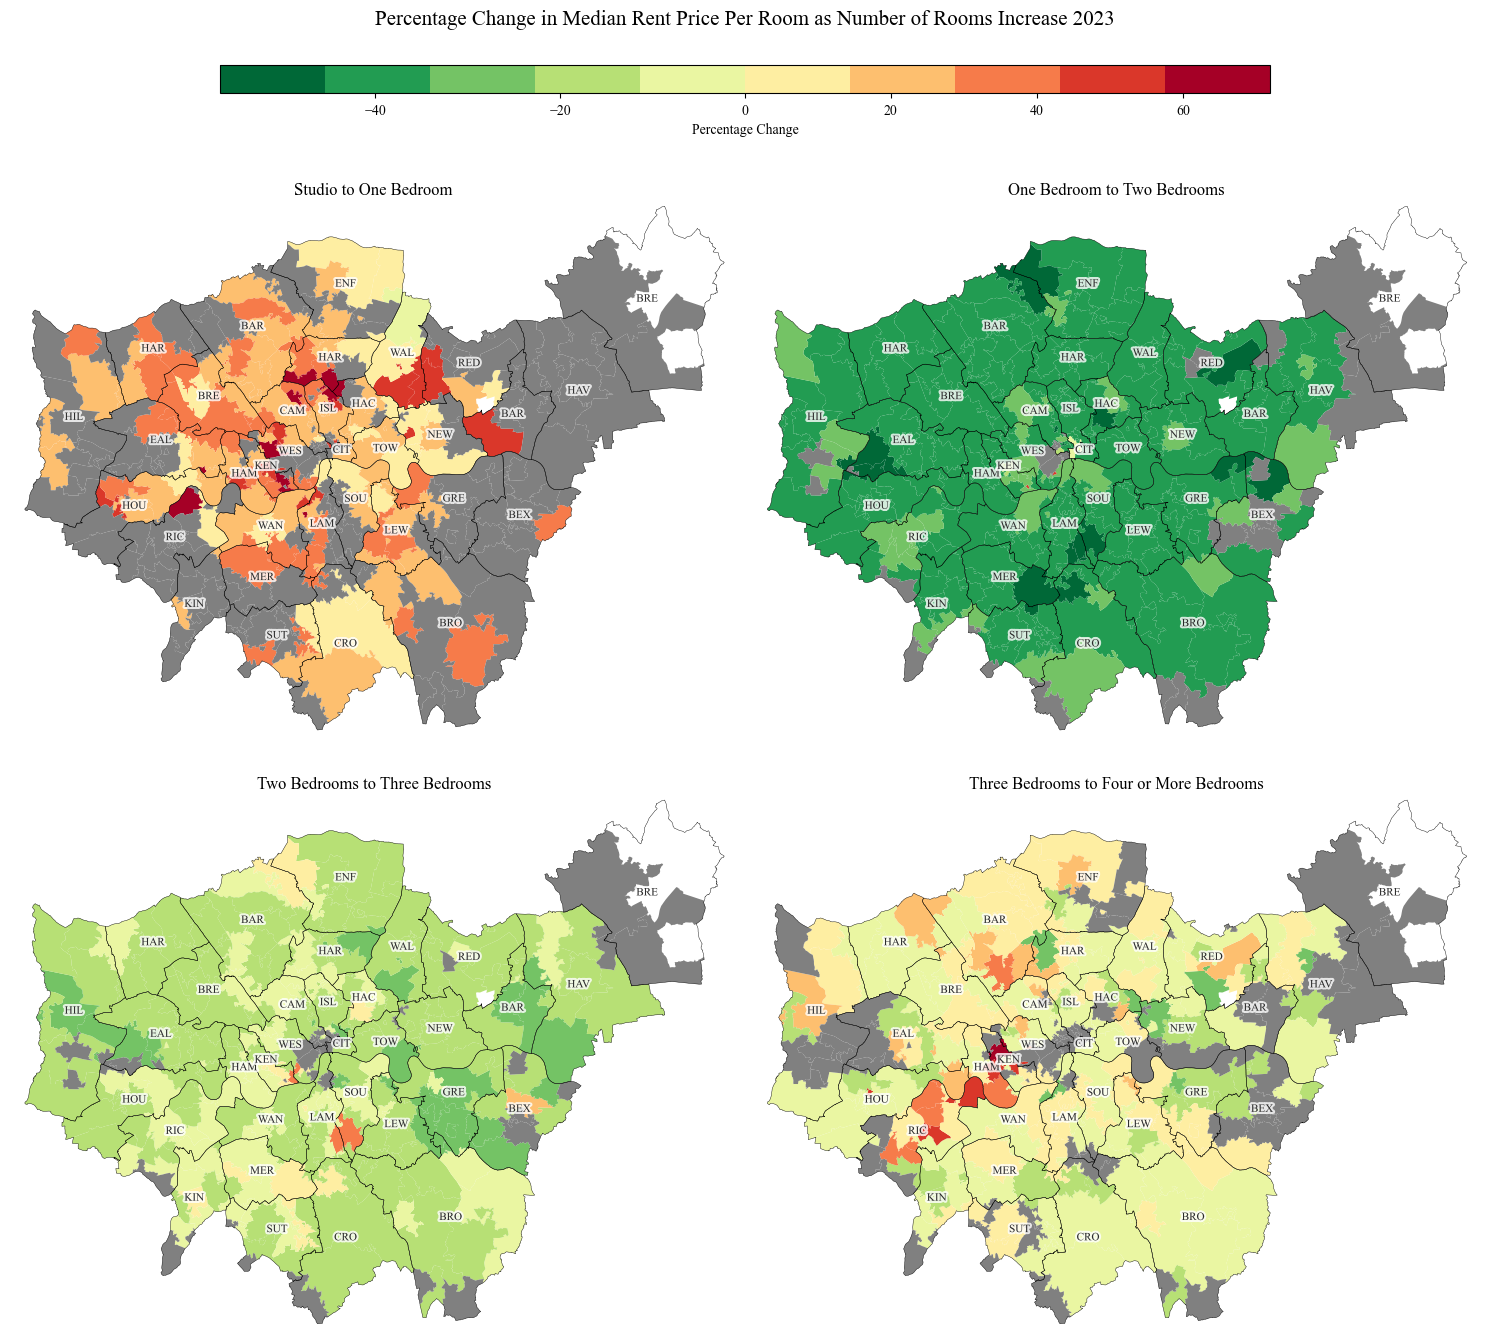

In [61]:
# median rent per room across London grouped by number of rooms per property
grouped_rent = rent_pct_change.groupby(['ROOM_TYPE'])
rooms = ['Studio', 'One Bedroom', 'Two Bedrooms', 'Three Bedrooms', 'Four or More Bedrooms']

# normalise rent data across every all room types
rent_min = rent_pct_change['RENT_PCT_CHANGE'].min()
rent_max = rent_pct_change['RENT_PCT_CHANGE'].max()
norm = TwoSlopeNorm(0, rent_min, rent_max)
#norm = plt.Normalize(rent_min, rent_max)

fig, axs = plt.subplots(2,2, figsize=(15,14))
plt.suptitle('Percentage Change in Median Rent Price Per Room as Number of Rooms Increase 2023', fontsize=15)
axs = axs.flatten()

for i, room in enumerate(rooms[1:]):
    ax=axs[i]
    df = grouped_rent.get_group((room,))
    mappable = plot_london(df, col='RENT_PCT_CHANGE', norm=norm, cmap='RdYlGn_r', cmap_bins=10, legend=False, ax=ax, return_mappable=True)
    plot_london(borough_outline, borough=True, edgecolour='black', ax=ax)
    ax.set_title(f'\n\n\n{rooms[i]} to {room}', fontsize=12)

# remove empty axes
[fig.delaxes(ax) for ax in axs if not ax.has_data()]
plt.tight_layout(rect=[0, 0, 1, 0.92])

# add colourbar
cbar_ax = fig.add_axes([0.15, 0.92, 0.7, 0.02])
plt.colorbar(mappable, label='Percentage Change', orientation='horizontal', cax=cbar_ax)

plt.savefig(os.path.join(base_dir, 'images', 'rent_pct_change_by_room_map.png'))
plt.show()

Rent per room increases the most between studio to one-bedroom flats with the largest increase in TW9, Richmond upon Thames showing a 72% increase. This could be due to the upgrade in space from the division of sleeping quarters from living quarters. A notable exception to this trend is the outcode E4 in Waltham Forest where rent decreases by 9.6%. There are 60 one-bedroom properties in this dataset for that outcode, on the lower end of rent count, which could be affecting the median rent price. The outcode borders Epping Forest.

The increase from three-bedroom flats to four-bedrooms also sees an increase in rent, especially concentrated in West London. This could possibly be reflecting the type of property being rented out since three-bed properties could be referring to flats, whereas four-or-more-bed properties could be referring to houses. Due to the large upfront cost of buying a house instead of a flat, landlords may charge more to rent out houses leading to this spike in the maps.

The largest decrease in rent is between one-bedroom flats to two-bedroom flats across the board, with areas in Lambeth and Camden seeing a rent decrease of around 50%. Upgrading from two-bedrooms to three-bedrooms also sees an average decrease of 15%. One area of Lambeth (SE21) increases in rent by %32.

Moving to a three-bedroom flat from a two-bedroom flat decreases rent per room a further -14% on average. For tenants looking to find the most economical flats in West London, sharing a three-bedroom seems to be the best option. Those looking to live in East London may find four or more bed houses less expensive.

# Rent and Transport Correlation

In [62]:
# calculate the average rent as distance from each transport link increases
rent_dists = rent_dist_geometry.groupby(by='OUTCODE')[['MEDIAN_RENT_PR','DIST_TO_TUBE_STATION','DIST_TO_OVERGROUND_STATION','DIST_TO_TRAM_STATION','DIST_TO_DLR_STATION','DIST_TO_ELIZABETH LINE_STATION']].mean()

# bin distances from transport links
bins = ['<0.1km', '0.1km-0.2km', '0.2km-0.5km', '0.5km-1km', '1km-2km', '2km-3km', '3km-5km', '5km-10km', '10km-15km', '15km-20km', '>20km']
for col in dist_cols:
    rent_dists[f'{col}_BINNED'] = pd.cut(rent_dists[col], [-1,0.1,0.2,0.5,1,2,3,5,10,15,20,100], labels=bins, right=False)
dist_cols_binned = rent_dists.columns[rent_dists.columns.str.contains('BINNED')].tolist()
rent_dists_binned = rent_dists[['MEDIAN_RENT_PR'] + dist_cols_binned]
baseline_rent = rent_dists['MEDIAN_RENT_PR'].median()

med_rents_per_dist = pd.DataFrame(index=bins)
for col in dist_cols_binned:
    transport = col[8:-15]
    med_rents_per_dist[f'MEDIAN_RENT_PR_{transport}'] = rent_dists_binned[['MEDIAN_RENT_PR', col]].groupby(col, observed=False).median()
med_rents_per_dist

,MEDIAN_RENT_PR_TUBE,MEDIAN_RENT_PR_ELIZABETH LINE,MEDIAN_RENT_PR_DLR,MEDIAN_RENT_PR_OVERGROUND,MEDIAN_RENT_PR_TRAM
<0.1km,NaN,NaN,NaN,NaN,NaN
0.1km-0.2km,1368.600000,949.333333,1084.200000,960.600000,NaN
0.2km-0.5km,1210.250000,857.250000,1097.600000,962.883333,775.666667
0.5km-1km,1059.083333,1408.350000,1128.166667,1089.600000,900.466667
1km-2km,842.500000,1179.166667,1017.550000,1119.500000,800.000000
2km-3km,960.600000,1074.500000,1088.250000,1028.800000,804.200000
3km-5km,800.000000,850.333333,1049.400000,845.966667,811.750000
5km-10km,783.333333,915.000000,908.266667,800.000000,1052.500000
10km-15km,800.350000,815.600000,872.383333,750.500000,1082.600000
15km-20km,701.000000,786.500000,829.333333,NaN,867.166667


In [77]:
# calculate absolute premiums of living closer to transport links
premiums = med_rents_per_dist-baseline_rent
premiums.columns = premiums.columns.str.slice(start=15)
premiums = premiums.reset_index(names='DISTANCE')
premiums = pd.melt(premiums, id_vars=['DISTANCE'], var_name='TRANSPORT', value_name='PREMIUM_£')

# save table
markdown_table = premiums.nlargest(20, 'PREMIUM_£').to_markdown(index=False, tablefmt='github')
filepath = os.path.join(base_dir, 'tables', 'top_10_premiums.md')
with open(filepath, "w") as f:
    f.write(markdown_table)
premiums.nlargest(10, 'PREMIUM_£').style.hide(axis='index')

DISTANCE,TRANSPORT,PREMIUM_£
0.5km-1km,ELIZABETH LINE,521.766667
0.1km-0.2km,TUBE,482.016667
0.2km-0.5km,TUBE,323.666667
1km-2km,ELIZABETH LINE,292.583333
0.5km-1km,DLR,241.583333
1km-2km,OVERGROUND,232.916667
0.2km-0.5km,DLR,211.016667
0.5km-1km,OVERGROUND,203.016667
2km-3km,DLR,201.666667
0.1km-0.2km,DLR,197.616667


Using the median rent per room across London as a baseline rent, we can find the premiums associated with living closer to certain transport links. Living within 500m and 1km from the Elizabeth line has the highest premium of £521. This is followed by a £482 premium of living within 100m and 200m of a tube station. The large difference in distance between the two could be due to the Elizabeth line running above ground for portions of the track. The noise attached to this could drive down rental prices within short distances of a station. On the other hand the tube is always underground and produces minimal noise so there is no radius in which rental prices decrease.

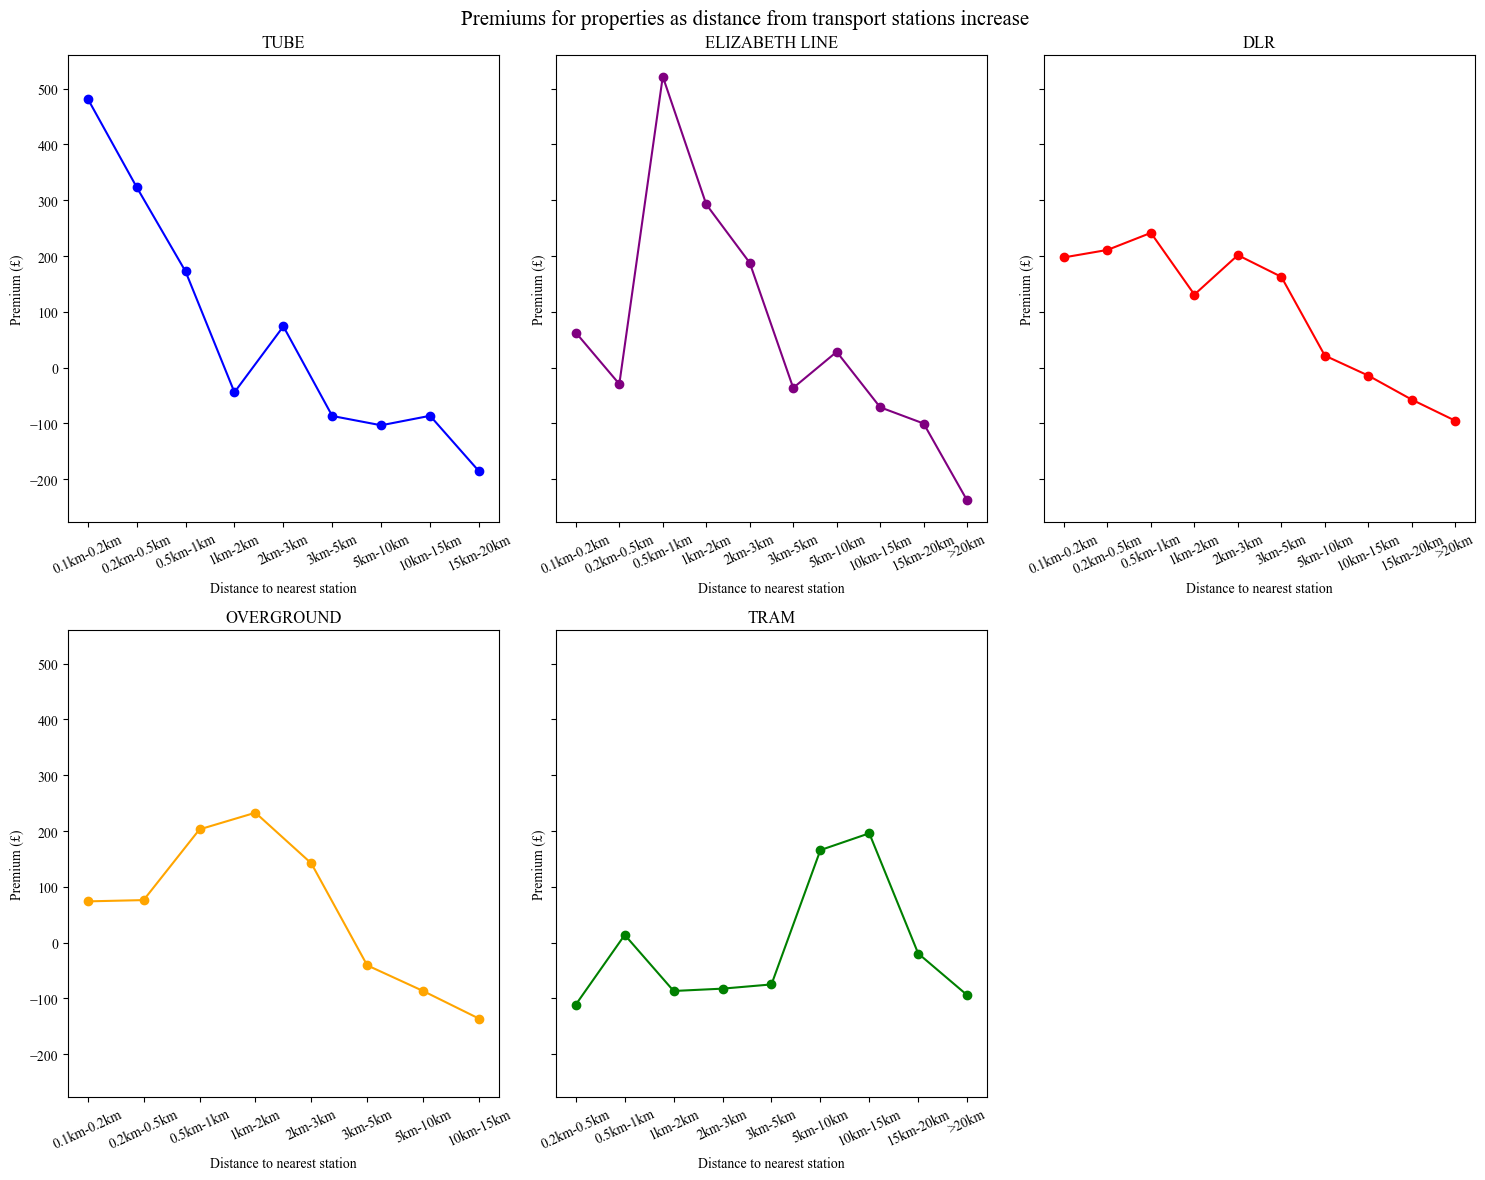

In [78]:
# visualise premiums
grouped_premiums = premiums.groupby('TRANSPORT')

fig, axs = plt.subplots(2,3, figsize=(15,12), sharey=True)
plt.suptitle('Premiums for properties as distance from transport stations increase', fontsize=15)
axs = axs.flatten()

for i, transport in enumerate(transport_names):
    ax=axs[i]
    df = grouped_premiums.get_group(transport.upper())
    ax.plot(df.DISTANCE, df['PREMIUM_£'], '-o', c=transport_colours[transport.lower()])
    ax.tick_params('x', rotation=25)
    ax.set_ylabel('Premium (£)')
    ax.set_title(transport.upper(), fontsize=12)
    ax.set_xlabel('Distance to nearest station')

# remove empty axes
[fig.delaxes(ax) for ax in axs if not ax.has_data()]
plt.tight_layout()

# save image
plt.savefig(os.path.join(base_dir, 'images', 'premiums_per_transport.png'))
plt.show()

In [65]:
# calculate the average rent as distance from each transport link increases
rent_dists_sep_by_room_type = rent_dist_geometry.groupby(by=['OUTCODE', 'ROOM_TYPE'])[['MEDIAN_RENT_PR','DIST_TO_TUBE_STATION','DIST_TO_OVERGROUND_STATION','DIST_TO_TRAM_STATION','DIST_TO_DLR_STATION','DIST_TO_ELIZABETH LINE_STATION']].mean()
#display(rent_dists_sep_by_room_type)

# bin distances from transport links
bins = ['<0.1km', '0.1km-0.2km', '0.2km-0.5km', '0.5km-1km', '1km-2km', '2km-3km', '3km-5km', '5km-10km', '10km-15km', '15km-20km', '>20km']
for col in dist_cols:
    rent_dists_sep_by_room_type[f'{col}_BINNED'] = pd.cut(rent_dists_sep_by_room_type[col], [-1,0.1,0.2,0.5,1,2,3,5,10,15,20,100], labels=bins, right=False)
dist_cols_binned = rent_dists_sep_by_room_type.columns[rent_dists_sep_by_room_type.columns.str.contains('BINNED')].tolist()
rent_dists_sep_by_room_type_binned = rent_dists_sep_by_room_type[['MEDIAN_RENT_PR'] + dist_cols_binned]
baseline_rent_sep_by_room_type = rent_dists_sep_by_room_type.groupby('ROOM_TYPE')['MEDIAN_RENT_PR'].median()

med_rents_per_dist_sep_by_room_type = []
for col in dist_cols_binned:
    transport = col[8:-15]
    df = rent_dists_sep_by_room_type_binned[['MEDIAN_RENT_PR', col]].rename(columns={col:'DISTANCE', 'MEDIAN_RENT_PR':f'MEDIAN_RENT_PR_{transport}'}).groupby(['ROOM_TYPE', 'DISTANCE'], observed=False).median()
    med_rents_per_dist_sep_by_room_type.append(df)
med_rents_per_dist_sep_by_room_type = pd.concat(med_rents_per_dist_sep_by_room_type, axis=1)
med_rents_per_dist_sep_by_room_type

MEDIAN_RENT_PR_TUBE  \
ROOM_TYPE             DISTANCE                           
Four or More Bedrooms <0.1km                       NaN   
                      0.1km-0.2km                625.0   
                      0.2km-0.5km                862.0   
                      0.5km-1km                  875.0   
                      1km-2km                    684.0   
...                                                ...   
Two Bedrooms          3km-5km                    725.0   
                      5km-10km                   718.5   
                      10km-15km                  740.0   
                      15km-20km                  675.0   
                      >20km                        NaN   

                                   MEDIAN_RENT_PR_ELIZABETH LINE  \
ROOM_TYPE             DISTANCE                                     
Four or More Bedrooms <0.1km                                 NaN   
                      0.1km-0.2km                          684.0   
                      0.2km-0.5km                          563.0   
                      0.5km-1km                            800.0   
                      1km-2km                              875.0   
...                                                          ...   
Two Bedrooms          3km-5km                              825.0   
                      5km-10km                             800.0   
                      10km-15km                            750.0   
                      15km-20km                            706.0   
                      >20km                                681.0   

                                   MEDIAN_RENT_PR_DLR  \
ROOM_TYPE             DISTANCE                          
Four or More Bedrooms <0.1km                      NaN   
                      0.1km-0.2km                 NaN   
                      0.2km-0.5km               575.0   
                      0.5km-1km                 862.0   
                      1km-2km                   790.0   
...                                               ...   
Two Bedrooms          3km-5km                   975.0   
                      5km-10km                  812.5   
                      10km-15km                 775.0   
                      15km-20km                 750.0   
                      >20km                     721.0   

                                   MEDIAN_RENT_PR_OVERGROUND  \
ROOM_TYPE             DISTANCE                                 
Four or More Bedrooms <0.1km                             NaN   
                      0.1km-0.2km                      790.0   
                      0.2km-0.5km                      800.0   
                      0.5km-1km                        810.0   
                      1km-2km                          862.0   
...                                                      ...   
Two Bedrooms          3km-5km                          750.0   
                      5km-10km                         746.0   
                      10km-15km                        682.5   
                      15km-20km                          NaN   
                      >20km                              NaN   

                                   MEDIAN_RENT_PR_TRAM  
ROOM_TYPE             DISTANCE                          
Four or More Bedrooms <0.1km                       NaN  
                      0.1km-0.2km                  NaN  
                      0.2km-0.5km                550.0  
                      0.5km-1km                  687.5  
                      1km-2km                    612.5  
...                                                ...  
Two Bedrooms          3km-5km                    750.0  
                      5km-10km                   950.0  
                      10km-15km                  935.0  
                      15km-20km                  800.0  
                      >20km                      715.0  

[66 rows x 5 columns]

In [85]:
# calculate absolute premiums of living closer to transport links separated by room type
premiums_sep_by_room_type = med_rents_per_dist_sep_by_room_type-baseline_rent_sep_by_room_type
premiums_sep_by_room_type=[]
for room, df in med_rents_per_dist_sep_by_room_type.groupby('ROOM_TYPE'):
    premiums_sep_by_room_type.append(df-baseline_rent_sep_by_room_type[room])
premiums_sep_by_room_type = pd.concat(premiums_sep_by_room_type)
premiums_sep_by_room_type.columns = premiums_sep_by_room_type.columns.str.slice(start=15)
premiums_sep_by_room_type = premiums_sep_by_room_type.reset_index()
premiums_sep_by_room_type = pd.melt(premiums_sep_by_room_type, id_vars=['DISTANCE', 'ROOM_TYPE'], var_name='TRANSPORT', value_name='PREMIUM_£')

for room, df in premiums_sep_by_room_type.groupby('ROOM_TYPE'):
    print(room.upper())
    display(df.nlargest(10, 'PREMIUM_£').drop(columns=['ROOM_TYPE']).style.hide(axis='index'))
    print('\n')

FOUR OR MORE BEDROOMS


DISTANCE,TRANSPORT,PREMIUM_£
5km-10km,TRAM,206.000000
0.5km-1km,TUBE,200.000000
1km-2km,ELIZABETH LINE,200.000000
0.2km-0.5km,TUBE,187.000000
2km-3km,ELIZABETH LINE,187.000000
0.5km-1km,DLR,187.000000
1km-2km,OVERGROUND,187.000000
0.5km-1km,OVERGROUND,135.000000
5km-10km,DLR,130.000000
0.5km-1km,ELIZABETH LINE,125.000000




ONE BEDROOM


DISTANCE,TRANSPORT,PREMIUM_£
0.5km-1km,ELIZABETH LINE,600.000000
0.1km-0.2km,TUBE,500.000000
1km-2km,ELIZABETH LINE,500.000000
0.2km-0.5km,TUBE,400.000000
2km-3km,DLR,400.000000
0.2km-0.5km,DLR,350.000000
0.5km-1km,DLR,350.000000
10km-15km,TRAM,350.000000
1km-2km,OVERGROUND,323.500000
0.5km-1km,OVERGROUND,311.000000




ROOM


...

DISTANCE,TRANSPORT,PREMIUM_£
1km-2km,ELIZABETH LINE,458.000000
0.2km-0.5km,DLR,437.500000
0.5km-1km,ELIZABETH LINE,344.000000
0.1km-0.2km,TUBE,336.500000
0.1km-0.2km,DLR,305.000000
10km-15km,TRAM,271.500000
3km-5km,DLR,255.000000
0.2km-0.5km,TUBE,218.500000
1km-2km,OVERGROUND,212.500000
2km-3km,ELIZABETH LINE,200.000000




THREE BEDROOMS


DISTANCE,TRANSPORT,PREMIUM_£
0.1km-0.2km,TUBE,275.500000
0.2km-0.5km,TUBE,206.000000
0.5km-1km,TUBE,200.000000
0.5km-1km,OVERGROUND,175.000000
0.5km-1km,DLR,167.000000
1km-2km,OVERGROUND,167.000000
5km-10km,TRAM,167.000000
0.5km-1km,ELIZABETH LINE,157.000000
1km-2km,ELIZABETH LINE,145.000000
2km-3km,ELIZABETH LINE,135.000000




TWO BEDROOMS


DISTANCE,TRANSPORT,PREMIUM_£
0.1km-0.2km,TUBE,325.000000
0.5km-1km,ELIZABETH LINE,325.000000
1km-2km,ELIZABETH LINE,275.000000
0.2km-0.5km,TUBE,265.000000
0.5km-1km,DLR,250.000000
0.5km-1km,TUBE,200.000000
1km-2km,OVERGROUND,200.000000
2km-3km,ELIZABETH LINE,175.000000
0.2km-0.5km,DLR,175.000000
3km-5km,DLR,175.000000


Failed to fit DIST_TO_ELIZABETH LINE_STATION for Studio: Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to fit DIST_TO_DLR_STATION for Studio: Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to fit DIST_TO_TRAM_STATION for Studio: Optimal parameters not found: Number of calls to function has reached maxfev = 800.


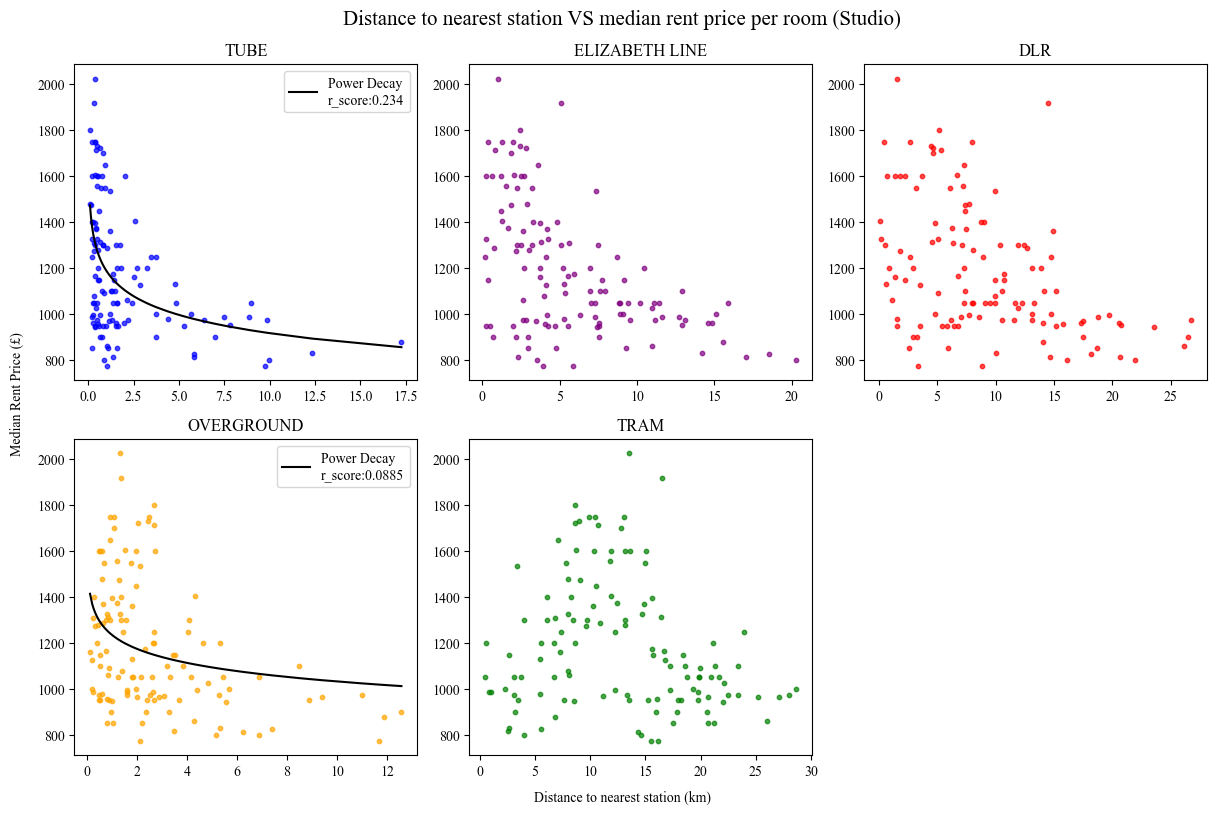

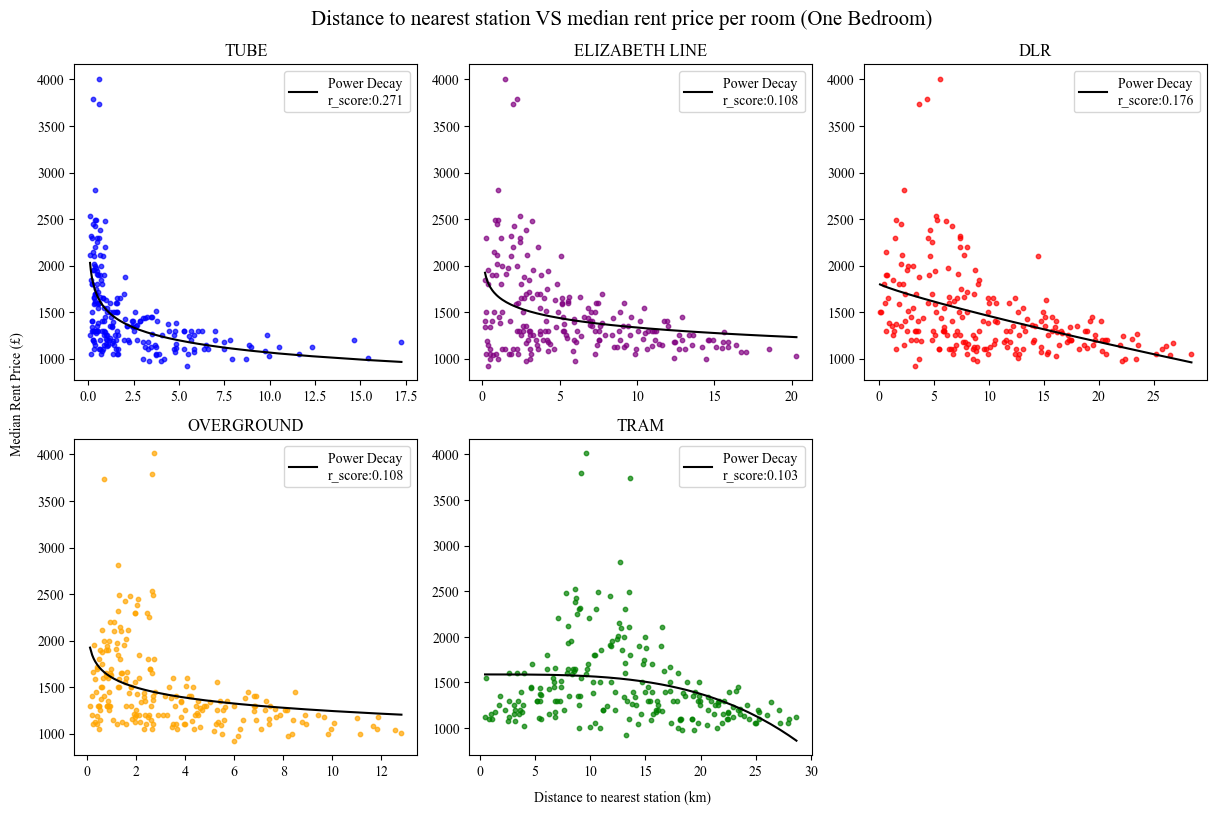

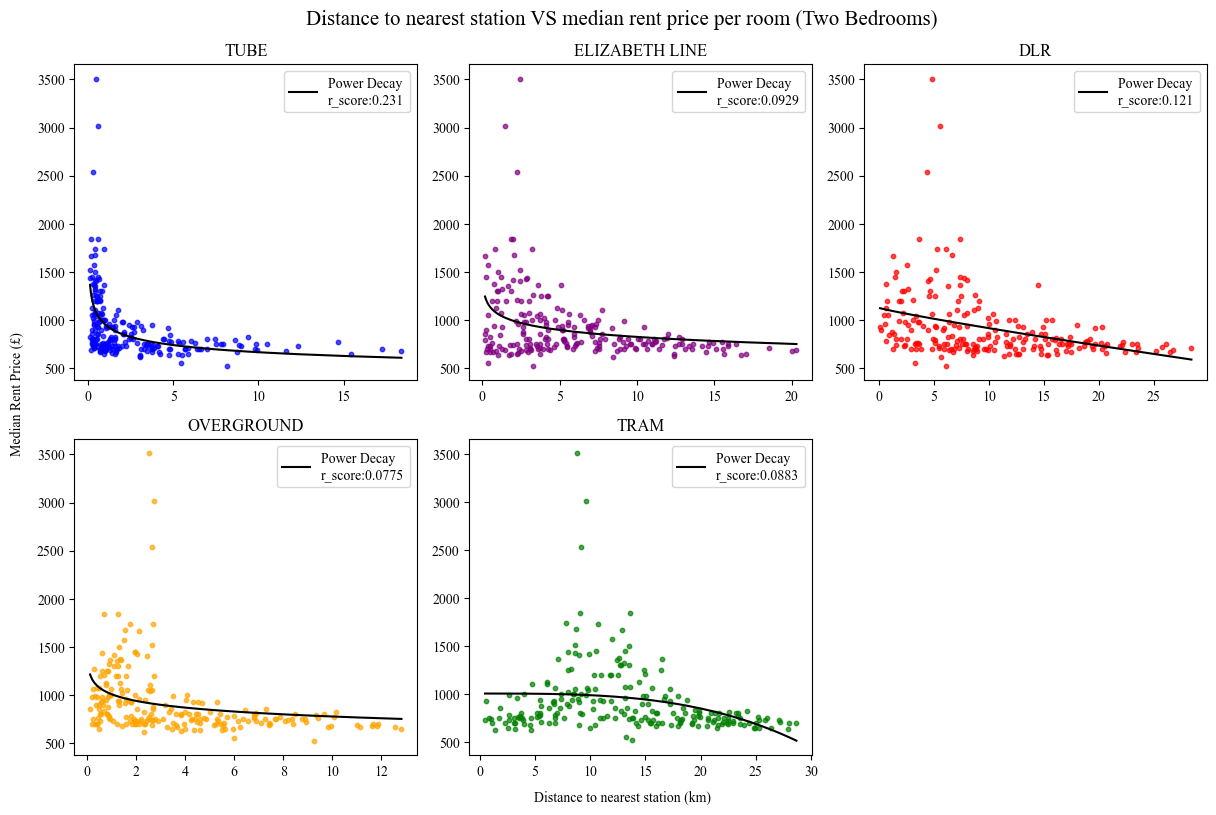

Failed to fit DIST_TO_DLR_STATION for Three Bedrooms: Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Failed to fit DIST_TO_TRAM_STATION for Three Bedrooms: Optimal parameters not found: Number of calls to function has reached maxfev = 800.


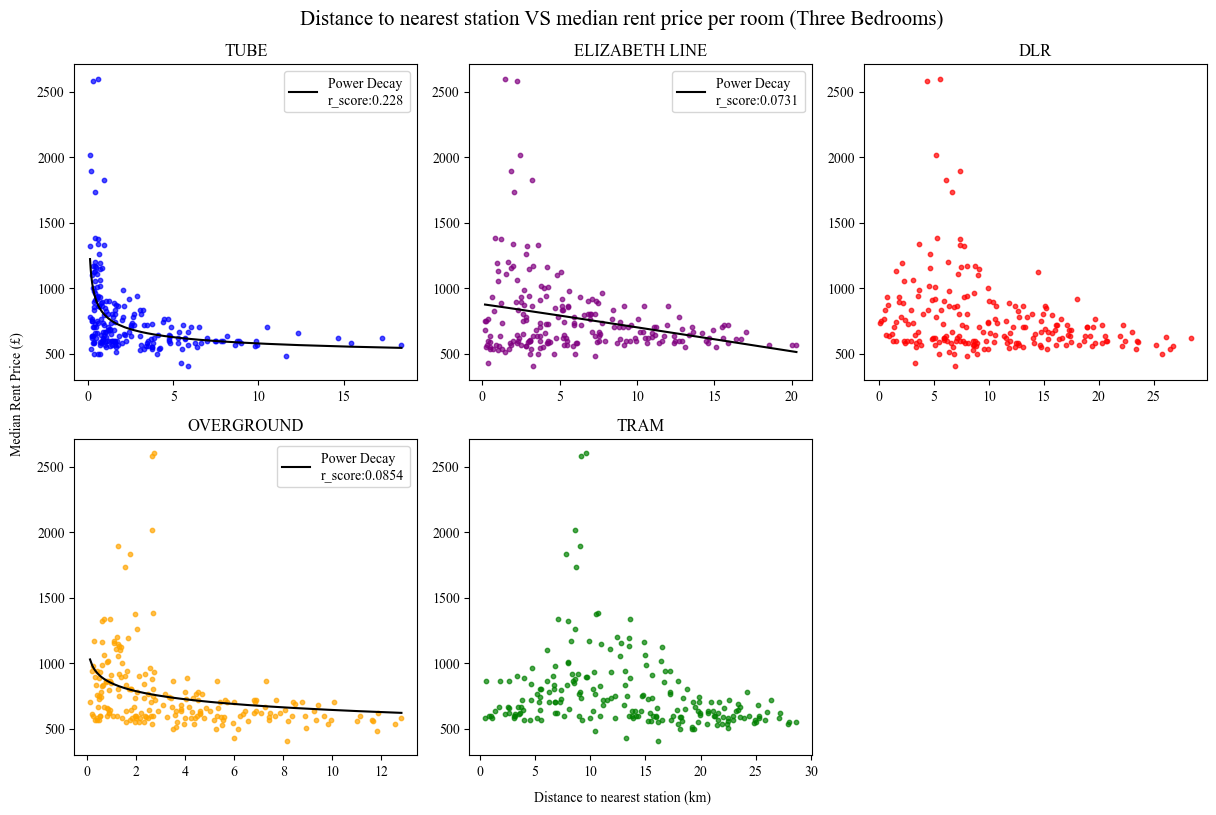

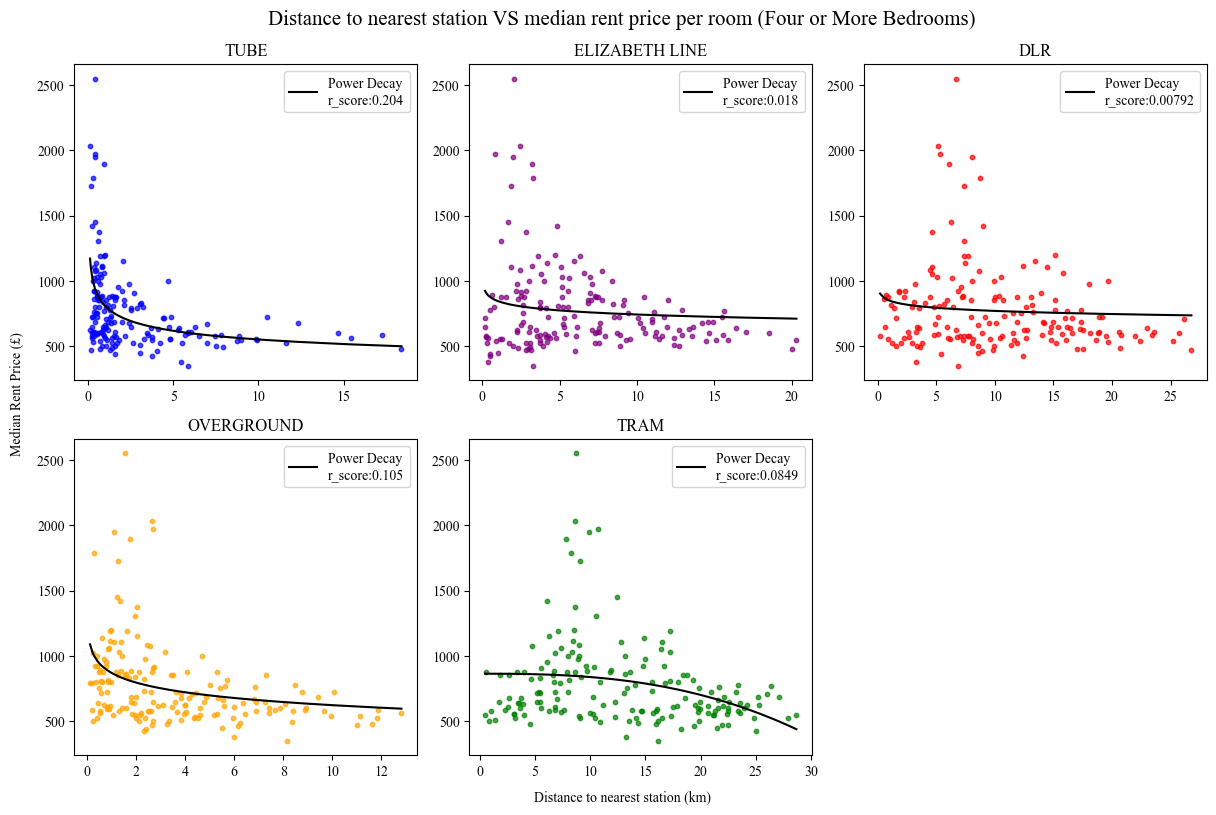

In [67]:
# plot distance to nearest station against median rent price per room
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

grouped_rooms = rent_dist_geometry.groupby('ROOM_TYPE')
room_types = ['Studio', 'One Bedroom', 'Two Bedrooms', 'Three Bedrooms', 'Four or More Bedrooms']
dist_cols = rent_dist_geometry.columns[rent_dist_geometry.columns.str.contains('DIST')].tolist()
colours = ['blue', 'orange', 'green', 'red', 'purple', 'grey']

def power_decay(x,a,b,c):
    return a*(x+0.01)**(-b) + c

for room in room_types:
    df = grouped_rooms.get_group(room)
    df = df.dropna()
    df = df[df.MEDIAN_RENT_PR!=0]
    fig, axs = plt.subplots(2,3,figsize=(12,8))
    axs=axs.flatten()
    for i, col in enumerate(dist_cols):
        transport = str(col[8:-8])
        axs[i].scatter(df[col], df.MEDIAN_RENT_PR, s=10, alpha=0.7, color=transport_colours[transport.lower()])
        axs[i].set_title(transport.upper())
        # power decay
        try:
            popt, pcov = curve_fit(power_decay, df[col], df.MEDIAN_RENT_PR)
            x_fit = np.sort(df[col])
            y_fit = power_decay(x_fit, *popt)
            r_score = r2_score(df.MEDIAN_RENT_PR, power_decay(df[col], *popt))
            axs[i].plot(x_fit, y_fit, 'black', label=f'Power Decay\nr_score:{r_score:.3}')
            axs[i].legend()
        except Exception as e:
            print(f"Failed to fit {col} for {room}: {e}")
            
    fig.text(0.5, -0.01, 'Distance to nearest station (km)', ha='center')
    fig.text(-0.01, 0.5, f'Median Rent Price (£)', va='center', rotation='vertical')
    fig.suptitle(f'Distance to nearest station VS median rent price per room ({room})', fontsize=15)

    # remove empty axes
    [fig.delaxes(ax) for ax in axs if not ax.has_data()]
    plt.tight_layout()
    plt.show()

Plotting the distance from the centre of each outcode to the nearest station against the median rent per room shows a small correlation. There is a premium for properties within 500m of a tube station, after which rents sharply drop. This pattern is most apparent in two-bedroom properties. Flats within 5km of the Elizabeth line also have a premium, likely be due to the overlap with the tube network.

TUBE: Spearman's Correlation: -0.403, p-value: 6.08e-38
ELIZABETH LINE: Spearman's Correlation: -0.245, p-value: 2.82e-14
DLR: Spearman's Correlation: -0.264, p-value: 1.99e-16
OVERGROUND: Spearman's Correlation: -0.339, p-value: 1.33e-26
TRAM: Spearman's Correlation: -0.177, p-value: 5.14e-08


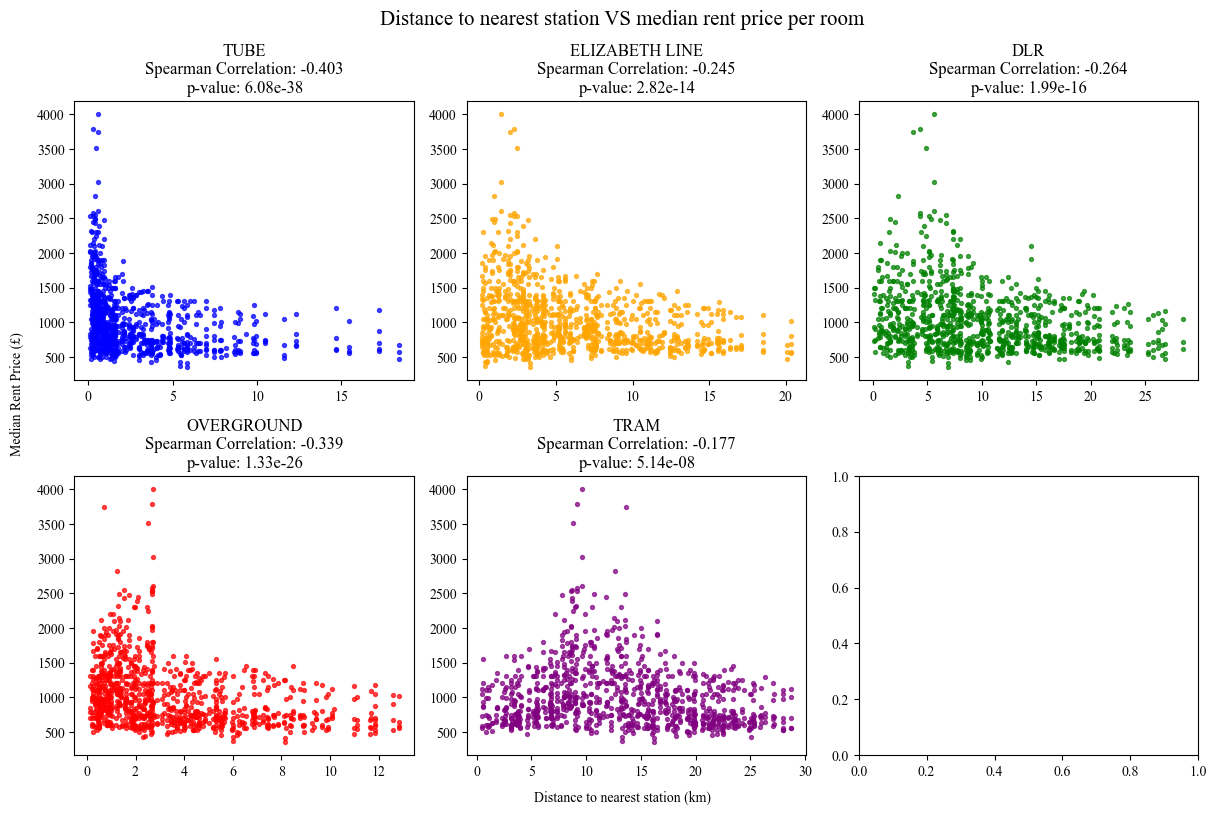

In [68]:
import scipy.stats as stats

fig, ax = plt.subplots(2,3,figsize=(12,8))
ax=ax.flatten()
filtered_data = rent_dist_geometry[rent_dist_geometry!=0]
filtered_data = filtered_data[filtered_data.ROOM_TYPE!='Room']

for i, col in enumerate(dist_cols):
    # calculate Spearman Correlation
    spearman_corr, p_value = stats.spearmanr(filtered_data.dropna()[col], filtered_data.dropna()['MEDIAN_RENT_PR'])
    print(f"{col[8:-8].upper()}: Spearman's Correlation: {spearman_corr:.3}, p-value: {p_value:.3}")
    ax[i].scatter(filtered_data[col], filtered_data.MEDIAN_RENT_PR, s=8, alpha=0.7, color=colours[i], label=col[8:-8].title())
    ax[i].set_title(f'{col[8:-8].upper()}\nSpearman Correlation: {spearman_corr:.3}\np-value: {p_value:.3}')
fig.text(0.5, -0.01, 'Distance to nearest station (km)', ha='center')
fig.text(-0.01, 0.5, f'Median Rent Price (£)', va='center', rotation='vertical')
fig.suptitle(f'Distance to nearest station VS median rent price per room', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'images', 'dist_to_station_against_median_rent'))
plt.show()

STUDIO: Spearman's Correlation: -0.503, p-value: 3.98e-09
ONE BEDROOM: Spearman's Correlation: -0.548, p-value: 1.94e-18
TWO BEDROOMS: Spearman's Correlation: -0.508, p-value: 6.92e-16
THREE BEDROOMS: Spearman's Correlation: -0.372, p-value: 2.57e-08
FOUR OR MORE BEDROOMS: Spearman's Correlation: -0.277, p-value: 0.000231


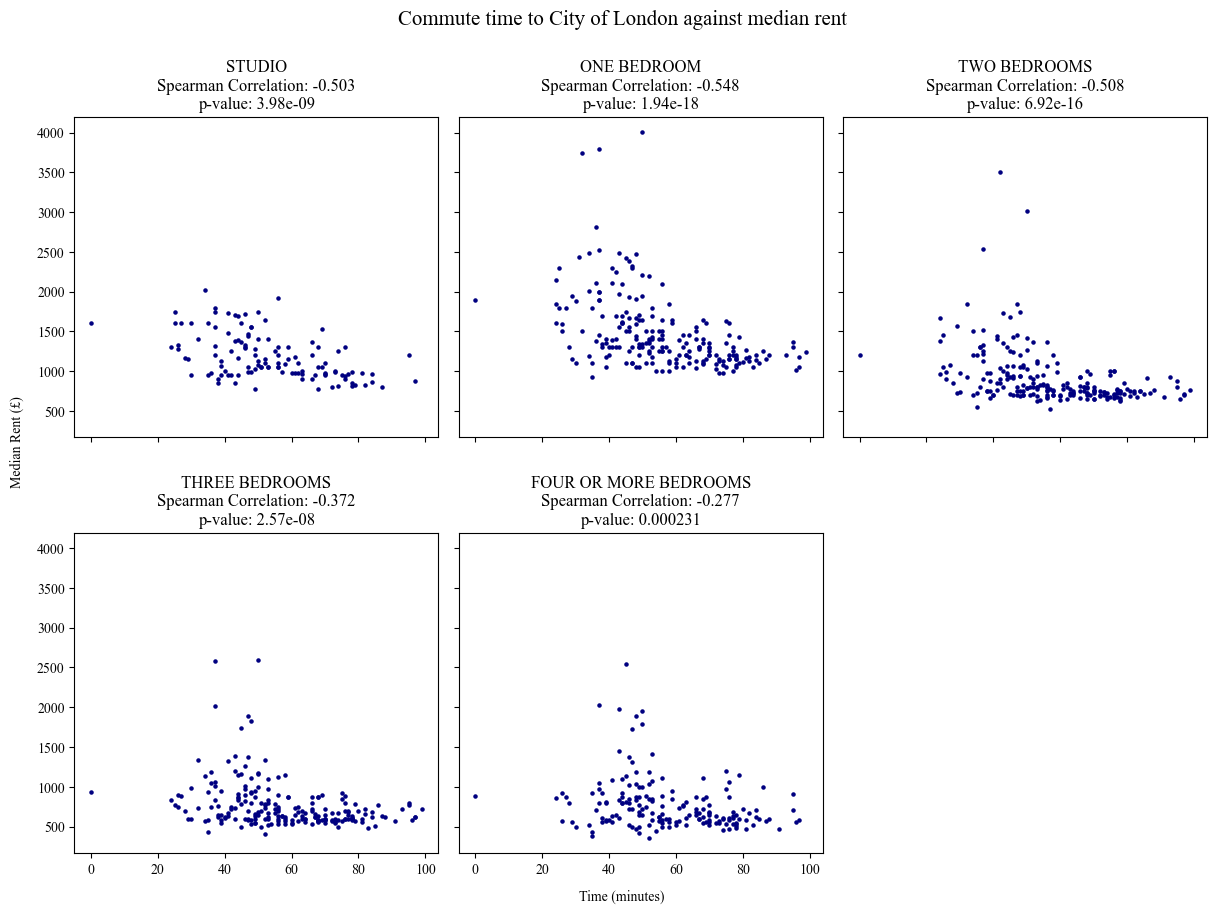

In [69]:
# plot journey time against median rent price per room
grouped_rooms = rent_dist_geometry.groupby('ROOM_TYPE')
room_types = ['Studio', 'One Bedroom', 'Two Bedrooms', 'Three Bedrooms', 'Four or More Bedrooms']

fig, axs = plt.subplots(2,3, figsize=(12,9), sharex=True, sharey=True)
axs = axs.flatten()
for i, room in enumerate(room_types):
    ax = axs[i]
    try:
        df = grouped_rooms.get_group(room).dropna()

        spearman_corr, p_value = stats.spearmanr(df.dropna()['JOURNEY_TIME'], df.dropna()['MEDIAN_RENT_PR'])
        print(f"{room.upper()}: Spearman's Correlation: {spearman_corr:.3}, p-value: {p_value:.3}")
        
        ax.scatter(df.JOURNEY_TIME, df.MEDIAN_RENT_PR, s=5, color='navy')
        ax.set_title(f'\n{room.upper()}\nSpearman Correlation: {spearman_corr:.3}\np-value: {p_value:.3}')
    except:
        continue
[fig.delaxes(ax) for ax in axs if not ax.has_data()]
fig.text(0.5, -0.01, 'Time (minutes)', ha='center')
fig.text(-0.01, 0.5, f'Median Rent (£)', va='center', rotation='vertical')
plt.suptitle('Commute time to City of London against median rent', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'images', 'commute_to_CoL_against_median_rent'))
plt.show()

The Spearman correlation between commute time to the centre of London and median rent per room is highest for one-bedroom flats followed by two-bedroom flats. This suggests that individuals living alone place a higher premium on accessibility, prioritising shorter commutes to offices. In contrast, those sharing larger houses may be more willing to tolerate longer travel times in exchange for lower rent. This pattern also highlights the distribution of employment, with single occupants being more likely to work in Central London while individuals living in shared accomodation have to compromise on location to find a place that offers a reasonable commute for each household member.

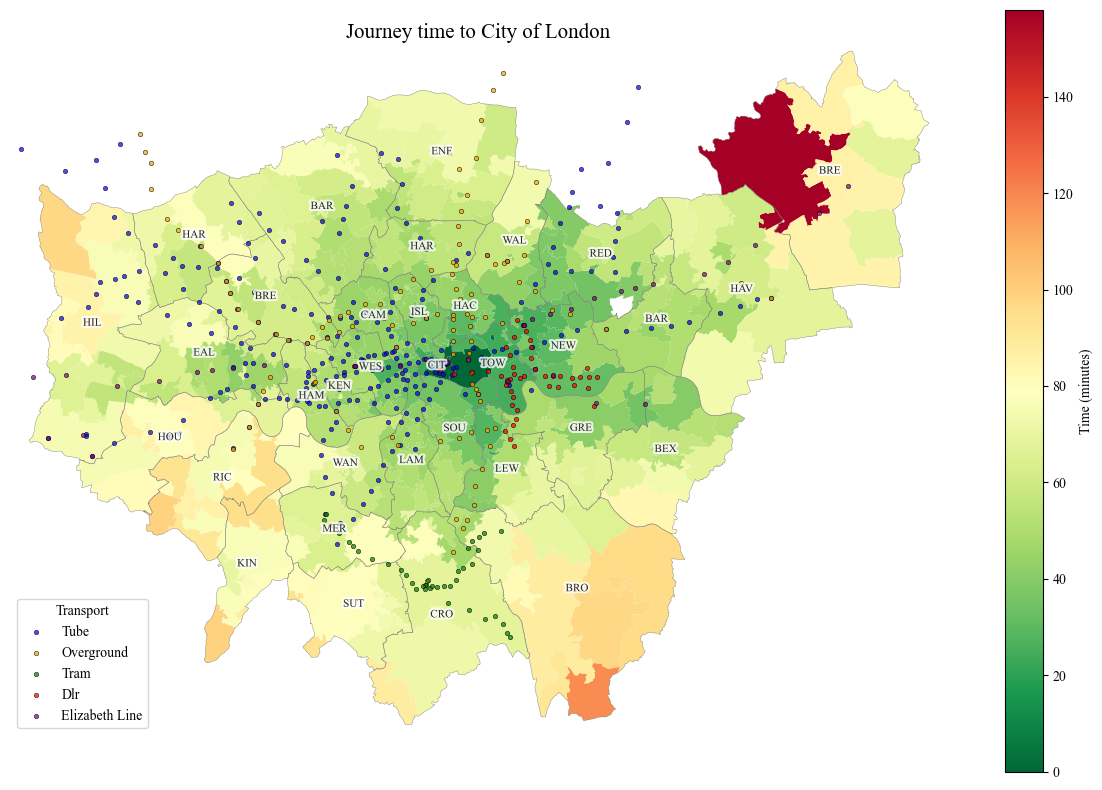

In [70]:
# journey times to the city centre
plt.figure(figsize=(12,8))
ax=plt.gca()
plot_london(outcode_outline, col='JOURNEY_TIME', cmap='RdYlGn_r', leg_label='Time (minutes)')
plot_london(borough_outline, borough=True)
plot_transport(transport_coords)
ax.set_title(f'Journey time to City of London', fontsize=15)
plt.legend(title='Transport', loc='lower left')
plt.tight_layout()
plt.show()

# Value Score
The value of each room is calculated by how inexpensive the rent is compared with the commute time to central London.

In [71]:
# calculate VALUE SCORE
def calculate_value(df, rent_weight=0.5, rent_col='MEDIAN_RENT_PR', journey_col='JOURNEY_TIME'):
    df = df.copy()
    assert 0 <= rent_weight <= 1, "rent_weight must be between 0 and 1"
    journey_weight = 1-rent_weight

    # map 0 values to np.nan
    rent_valid = df[rent_col].replace(0, np.nan)
    journey_valid = df[journey_col].replace(0, np.nan)

    # normalise data
    rent_norm = (rent_valid - rent_valid.min()) / (rent_valid.max() - rent_valid.min())
    journey_norm = (journey_valid - journey_valid.min()) / (journey_valid.max() - journey_valid.min())

    value_score = (rent_weight * (1-rent_norm)) + (journey_weight * (1-journey_norm))
    df['VALUE'] = value_score
    return df

rent_dist_value_geometry = calculate_value(rent_dist_geometry, 0.6)

In [76]:
# check the extremes
print('Highest VALUE scores (best trade-off):')
display(rent_dist_value_geometry.nlargest(5, 'VALUE')[['BOROUGH', 'OUTCODE', 'MEDIAN_RENT_PR', 'JOURNEY_TIME', 'VALUE']].style.hide(axis='index'))

df = rent_dist_value_geometry.nlargest(20, 'VALUE')[['BOROUGH', 'OUTCODE', 'MEDIAN_RENT_PR', 'JOURNEY_TIME', 'VALUE']]
markdown_table = df.to_markdown(index=False, tablefmt='github')
filepath = os.path.join(base_dir, 'tables', 'best_value_outcodes.md')
with open(filepath, "w") as f:
    f.write(markdown_table)

print('\nLowest VALUE scores (worst trade-off):')
display(rent_dist_value_geometry.nsmallest(5, 'VALUE')[['BOROUGH', 'OUTCODE', 'MEDIAN_RENT_PR', 'JOURNEY_TIME', 'VALUE']].style.hide(axis='index'))

df = rent_dist_value_geometry.nsmallest(20, 'VALUE')[['BOROUGH', 'OUTCODE', 'MEDIAN_RENT_PR', 'JOURNEY_TIME', 'VALUE']]
markdown_table = df.to_markdown(index=False, tablefmt='github')
filepath = os.path.join(base_dir, 'tables', 'worst_value_outcodes.md')
with open(filepath, "w") as f:
    f.write(markdown_table)

Highest VALUE scores (best trade-off):


BOROUGH,OUTCODE,MEDIAN_RENT_PR,JOURNEY_TIME,VALUE
Bexley,SE2,375.000000,35,0.963066
Newham,E13,500.000000,30,0.957499
Hackney,E15,575.000000,26,0.957145
Bexley,SE2,428.000000,35,0.954377
Redbridge,IG1,437.000000,35,0.952902



Lowest VALUE scores (worst trade-off):


BOROUGH,OUTCODE,MEDIAN_RENT_PR,JOURNEY_TIME,VALUE
Kensington and Chelsea,SW1X,4010.000000,50,0.322388
Westminster,SW1E,3792.000000,37,0.396932
Camden,N1C,3738.000000,32,0.420710
Kensington and Chelsea,SW1H,3510.000000,42,0.428236
Kensington and Chelsea,SW1X,3016.000000,50,0.485339


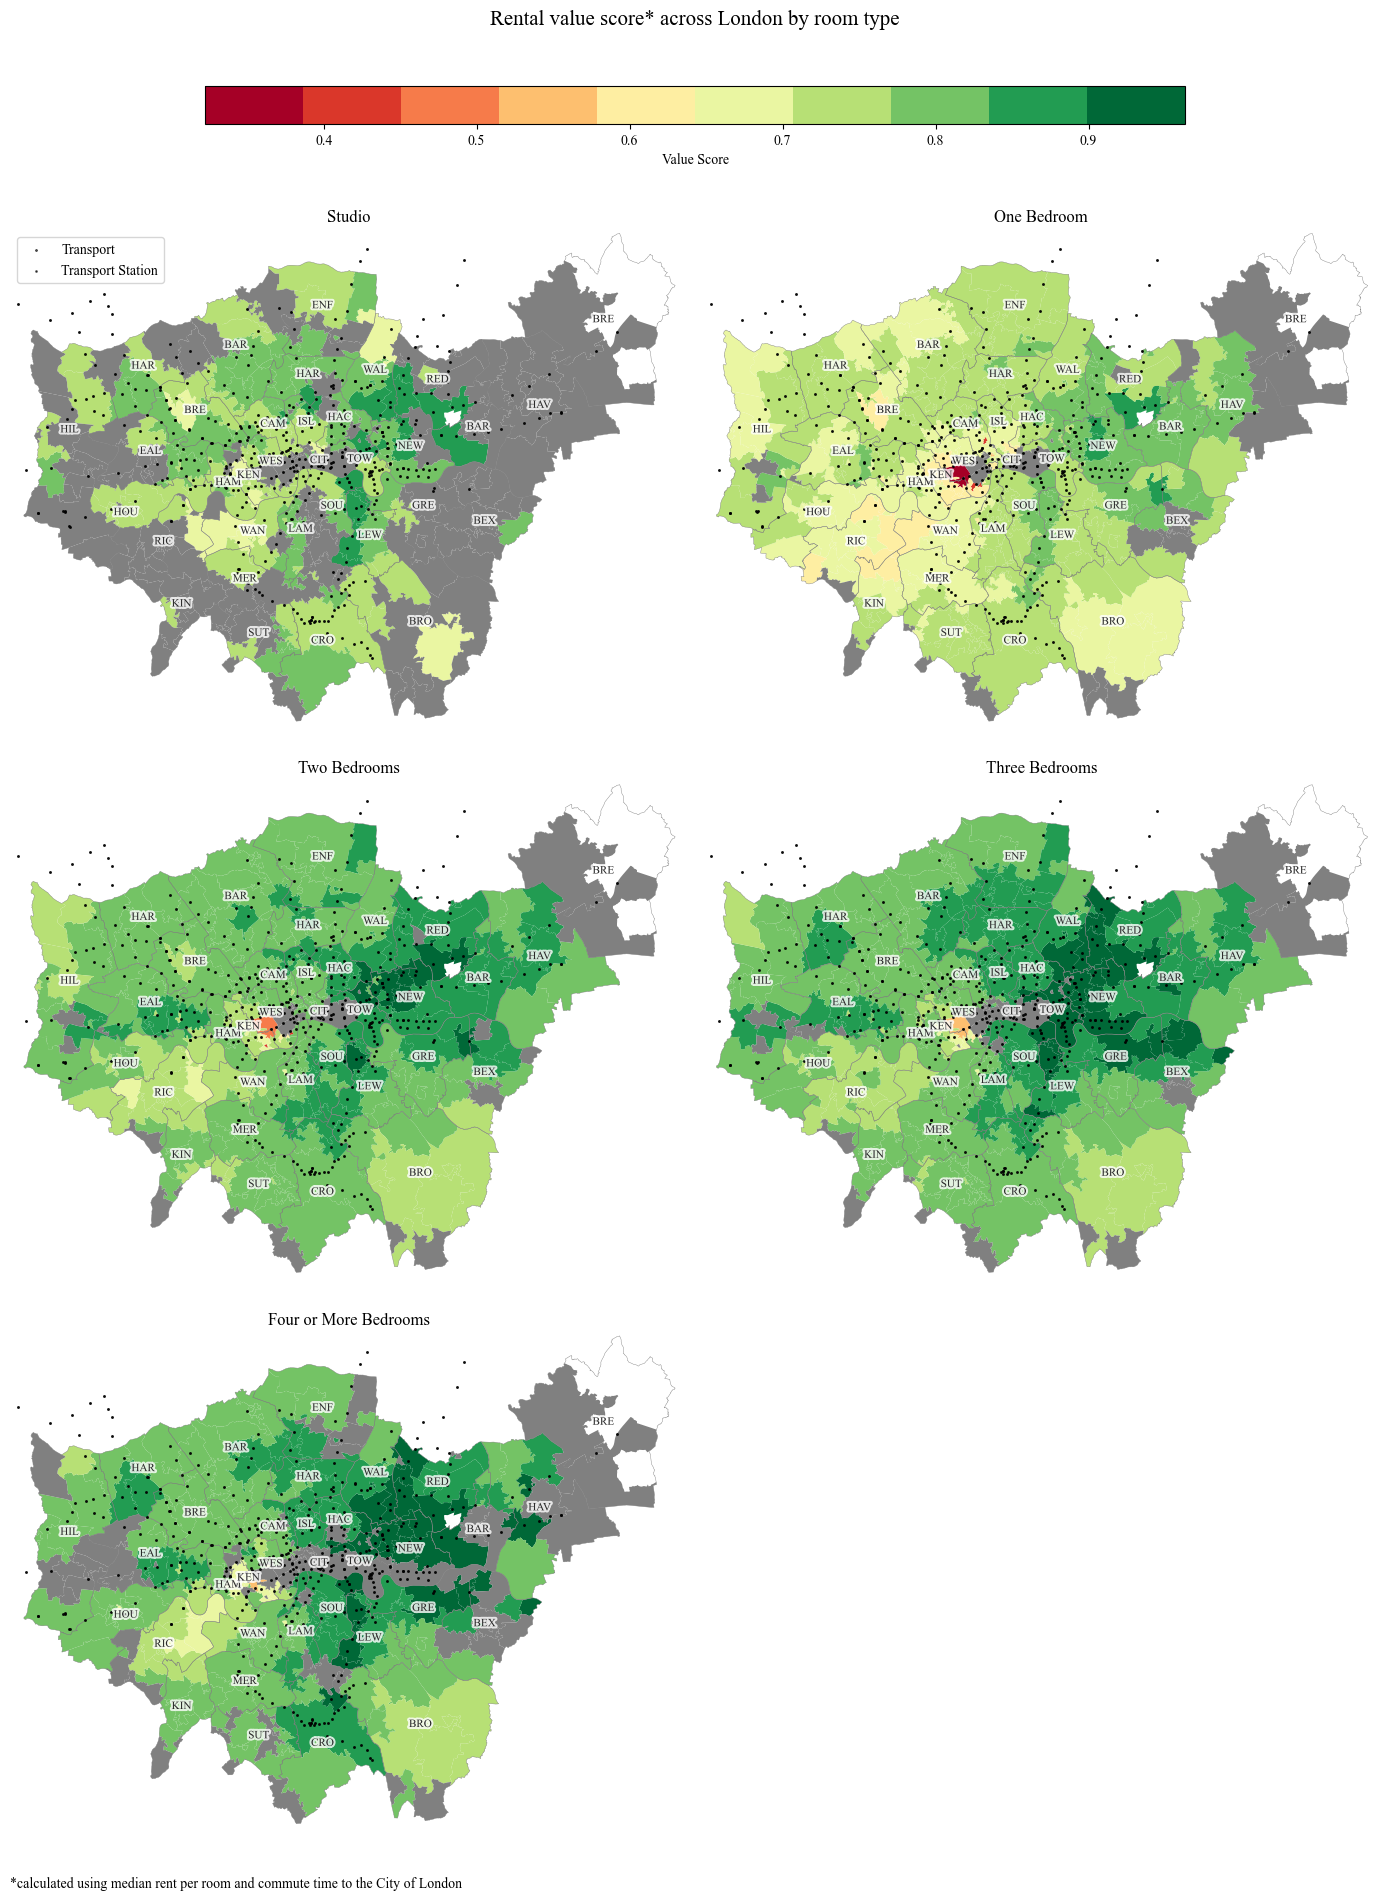

In [73]:
# Rent value per room across London
grouped_rent = rent_dist_value_geometry.groupby(['ROOM_TYPE'])
rooms = ['Studio', 'One Bedroom', 'Two Bedrooms', 'Three Bedrooms', 'Four or More Bedrooms']

# normalise data
val_min = rent_dist_value_geometry['VALUE'].min()
val_max = rent_dist_value_geometry['VALUE'].max()
norm = plt.Normalize(val_min, val_max)

fig, axs = plt.subplots(3,2, figsize=(14, 19))
plt.suptitle(f'Rental value score* across London by room type', fontsize=15)
axs = axs.flatten()
for i, room in enumerate(rooms):
    ax = axs[i]
    try:
        df = grouped_rent.get_group((room,))
        mappable = plot_london(df, col='VALUE', norm=norm, cmap_bins=10, legend=False, return_mappable=True, ax=ax)
        plot_london(borough_outline, borough=True, ax=ax)
        plot_transport(transport_coords, s=2, colour='black', ax=ax)
        ax.scatter(transport_coords['LON'], transport_coords['LAT'], s=1, c='black', alpha=0.6, label='Transport Station')
        if i==0:
            ax.legend(loc='upper left')
        ax.set_title(f'\n\n\n{room}', fontsize=12)
    except:
        ax.axis('off')
[fig.delaxes(ax) for ax in axs if not ax.has_data()]

# colourbar
plt.text(plt.xlim()[0],plt.ylim()[0]-0.05,'*calculated using median rent per room and commute time to the City of London')
plt.tight_layout(rect=[0, 0, 1, 0.92])
cbar_ax = fig.add_axes([0.15, 0.92, 0.7, 0.02])
plt.colorbar(mappable, label='Value Score', orientation='horizontal', cax=cbar_ax)

# save image
plt.savefig(os.path.join(base_dir, 'images', 'rental_value_map.png'))
plt.show()

The value score that combines rent affordability and ease of commute, shows that areas in East and Southeast London (Hackney, Newham, Bexley) provide the best trade-off for all property types. They provide cheaper rents (around £500 per room) along with short commute times around 30 minutes. Ealing is also noteworthy, likely due to the Elizabeth line.

On the other hand, Central and West London (Camden,     Westminster, Kensington and Chelsea) has the worst trade-off, with rent prices around £3500 per room, outweighing the shorter commute time. This shows that the areas with the best 'value' are not the central locations but those adjacent to the centre.